In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kendalltau, spearmanr, pearsonr
import search_results_lib as srl
import json

In [2]:
countries = [
    "Argentina",
    "Bolivia",
    "Chile",
    "Colombia",
    "Costa Rica",
    "Cuba",
    "Ecuador",
    "El Salvador",
    "Guatemala",
    "Honduras",
    "Mexico",
    "Nicaragua",
    "Panama",
    "Paraguay",
    "Peru",
    #"Puerto Rico",
    "Dominican Republic",
    "Uruguay",
    "Venezuela",
    "Spain"
]
n_countries = len(countries)
print(n_countries)  # 20
countries.sort()
df_dict = {}
corr_dict = {}

19


# Indices de corrupcion

In [3]:
path = "./indices/datasets/CPI2024-Results-and-trends.csv"
df_index = pd.read_csv(path, header=2, encoding="ISO-8859-1", sep=';')
df_index = df_index[df_index["Country / Territory"].isin(countries)]
df_index.dropna(how="all", axis=1, inplace=True)
df_index.rename(columns={"Country / Territory": "country"}, inplace=True)
df_index.set_index('country', inplace=True)

cpi2024_sources = {
    "rank": "Rank",
    "cpi": "CPI 2024 score",
    "gi": "S&P / Global Insights Country Risk Ratings",
    "prs": "PRS International Country Risk Guide",
    "vdem": "Varieties of Democracy Project",
    #"wef": "World Economic Forum EOS",
    "wjp": "World Justice Project Rule of Law cpi",
    "bti": "Bertelsmann Foundation Transformation cpi",
    "eiu": "Economist Intelligence Unit Country Ratings"
}
df_index.rename(columns=dict(zip(cpi2024_sources.values(), cpi2024_sources.keys())), inplace=True)

df_index.drop(columns=[i for i in df_index.columns if i not in cpi2024_sources.keys()], inplace=True)
df_index = df_index.reindex(countries)
df_index.dropna(how='all', inplace=True)
df_index.sort_index(inplace=True)
df_dict["cpi"] = df_index
df_index

,cpi,rank,eiu,gi,prs,vdem
country,,,,,,
Argentina,37,99,51.0,32.0,33.0,48.0
Bolivia,28,133,35.0,32.0,33.0,34.0
Chile,63,32,67.0,59.0,60.0,70.0
Colombia,39,92,51.0,46.0,33.0,48.0
Costa Rica,58,42,67.0,59.0,42.0,62.0
Cuba,41,82,51.0,32.0,49.0,35.0
Dominican Republic,36,104,51.0,32.0,24.0,32.0
Ecuador,32,121,35.0,32.0,33.0,30.0
El Salvador,30,130,35.0,32.0,33.0,27.0


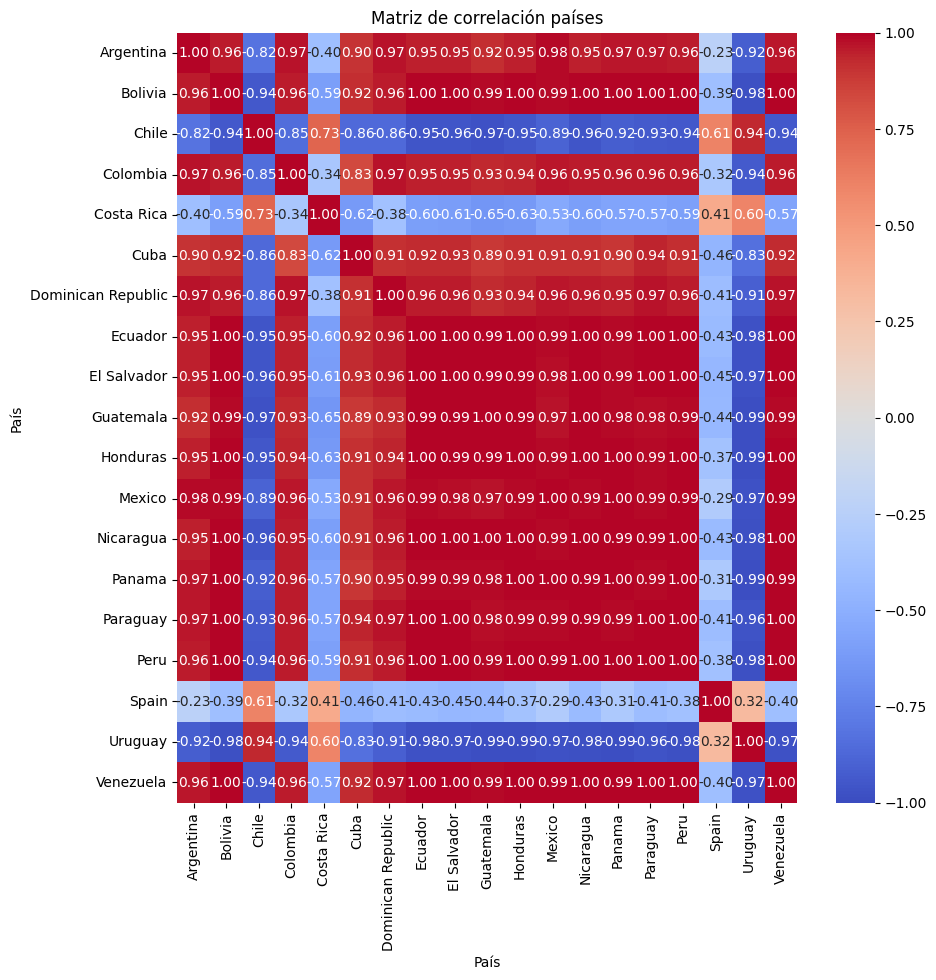

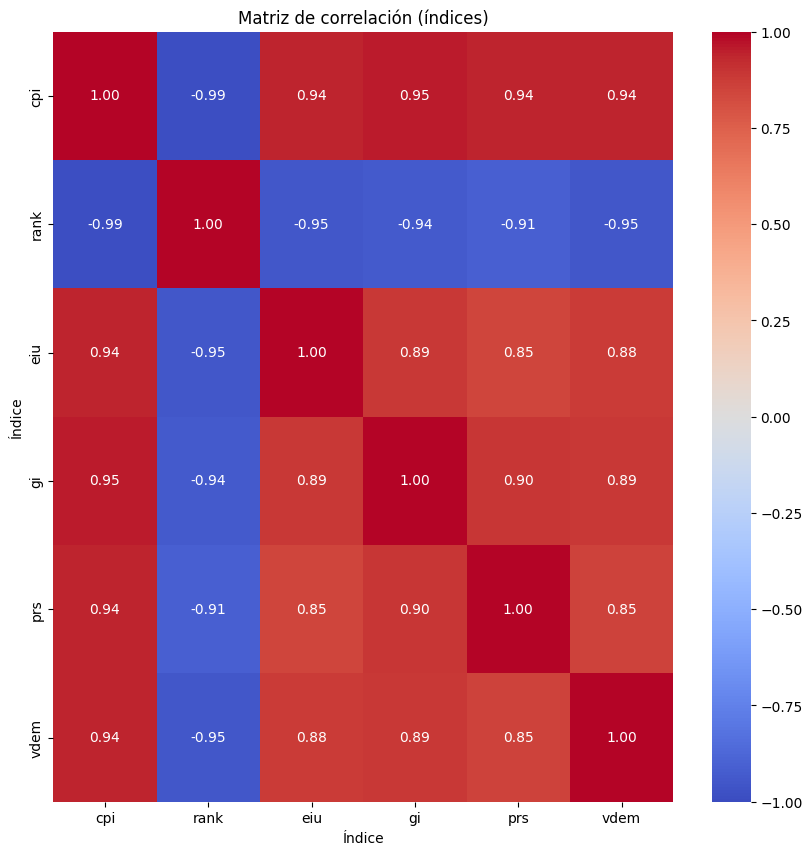

In [4]:
corr_dict['cpi'] = df_index.T.corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr_dict['cpi'], annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
#sns.heatmap(np.abs(index_corr), annot=True, cmap="coolwarm", vmin=0, vmax=1, fmt=".1f")
plt.title("Matriz de correlación países")
plt.xlabel("País")
plt.ylabel("País")
plt.show()

#corrT = correlation(df_index.T)

corr_dict['index-index'] = df_index.corr()

plt.figure(figsize=(10,10))
#sns.heatmap(index_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
sns.heatmap(corr_dict['index-index'], annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlación (índices)")
plt.xlabel("Índice")
plt.ylabel("Índice")
plt.show()

# Rankings resultados de busqueda

In [5]:
# Leer el archivo JSON guardado
Nombre_Archivo = f"./buscador/resultados/resultados_corrupcion.json"

with open(Nombre_Archivo, "r") as file:
    resultados = json.load(file)
for i in range(len(resultados)):
    if resultados[i]['country'] == 'Puerto Rico':
        resultados.pop(i)
        break
resultados.sort(key=lambda x: x['country'])

# Leer el archivo JSON guardado
Nombre_Archivo = f"./buscador/resultados/res_unicos_corrupcion.json"

with open(Nombre_Archivo, "r") as file:
    all_hrefs = json.load(file)

max_len = max([len(r['search_results']['results']) for r in resultados])
rankings = {}
for r in resultados:
    pages = [all_hrefs.index(res['href']) for res in r['search_results']['results']]
    if len(pages) < max_len:
        diff = max_len - len(pages)
        pages += [np.nan] * diff
    rankings[r['country']] = pages
df_rankings = pd.DataFrame(rankings).T
df_rankings.sort_index(inplace=True)
df_dict["rankings"] = df_rankings
df_rankings

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Argentina,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,90.0,91.0,92.0,93.0,94.0,95.0,96.0,97.0,98.0,99.0
Bolivia,0.0,1.0,3.0,5.0,2.0,4.0,28.0,100.0,55.0,101.0,...,153.0,154.0,155.0,97.0,156.0,157.0,65.0,158.0,59.0,NaN
Chile,1.0,4.0,159.0,160.0,3.0,2.0,5.0,33.0,161.0,144.0,...,51.0,208.0,116.0,209.0,125.0,210.0,211.0,212.0,139.0,82.0
Colombia,0.0,1.0,3.0,2.0,4.0,5.0,28.0,8.0,119.0,43.0,...,266.0,75.0,144.0,132.0,124.0,146.0,267.0,131.0,86.0,268.0
Costa Rica,1.0,3.0,2.0,4.0,5.0,158.0,28.0,269.0,270.0,271.0,...,137.0,59.0,82.0,125.0,155.0,298.0,299.0,300.0,NaN,NaN
Cuba,0.0,1.0,2.0,3.0,4.0,5.0,28.0,55.0,43.0,8.0,...,315.0,30.0,299.0,141.0,153.0,316.0,32.0,101.0,NaN,NaN
Dominican Republic,0.0,1.0,3.0,2.0,4.0,5.0,106.0,120.0,28.0,527.0,...,300.0,475.0,79.0,361.0,127.0,344.0,143.0,155.0,31.0,312.0
Ecuador,1.0,3.0,159.0,5.0,317.0,2.0,4.0,63.0,318.0,319.0,...,68.0,136.0,353.0,96.0,138.0,58.0,153.0,NaN,NaN,NaN
El Salvador,0.0,1.0,2.0,3.0,4.0,5.0,28.0,354.0,55.0,43.0,...,143.0,158.0,138.0,140.0,209.0,53.0,314.0,77.0,362.0,203.0
Guatemala,0.0,1.0,2.0,3.0,5.0,4.0,49.0,116.0,28.0,294.0,...,285.0,382.0,312.0,146.0,51.0,131.0,383.0,166.0,360.0,384.0


# Matriz de distancia entre capitales

In [6]:
capital_coords = {
    "Argentina": (-34.6037, -58.3816),            # Buenos Aires
    "Bolivia": (-16.4897, -68.1193),              # La Paz (sede de gobierno)
    "Chile": (-33.4489, -70.6693),                 # Santiago
    "Colombia": (4.7110, -74.0721),                # Bogotá
    "Costa Rica": (9.9281, -84.0907),              # San José
    "Cuba": (23.1136, -82.3666),                   # La Habana
    "Ecuador": (-0.1807, -78.4678),                # Quito
    "El Salvador": (13.6929, -89.2182),            # San Salvador
    "Guatemala": (14.6349, -90.5061),              # Ciudad de Guatemala
    "Honduras": (14.0723, -87.1921),               # Tegucigalpa
    "Mexico": (19.4326, -99.1332),                 # Ciudad de México
    "Nicaragua": (12.1140, -86.2362),              # Managua
    "Panama": (8.9824, -79.5199),                  # Ciudad de Panamá
    "Paraguay": (-25.2637, -57.5759),              # Asunción
    "Peru": (-12.0464, -77.0428),                  # Lima
    #"Puerto Rico": (18.4655, -66.1057),            # San Juan
    "Dominican Republic": (18.4861, -69.9312),     # Santo Domingo
    "Uruguay": (-34.9011, -56.1645),               # Montevideo
    "Venezuela": (10.4806, -66.9036),              # Caracas
    "Spain": (40.4168, -3.7038)                    # Madrid
}

D = np.zeros((n_countries, n_countries), dtype=float)

for i, ci in enumerate(countries):
    for j, cj in enumerate(countries):
        if i == j:
            D[i, j] = 0.0
        else:
            D[i, j] = srl.haversine_km(capital_coords[ci], capital_coords[cj])

# DataFrame cuadrado país x país (normalizado 0..1)
corr_dict['geo'] = pd.DataFrame(D/D.max(), index=countries, columns=countries)
corr_dict['geo']

,Argentina,Bolivia,Chile,Colombia,Costa Rica,Cuba,Dominican Republic,Ecuador,El Salvador,Guatemala,Honduras,Mexico,Nicaragua,Panama,Paraguay,Peru,Spain,Uruguay,Venezuela
Argentina,0.000000,0.208884,0.106421,0.436413,0.527375,0.644683,0.563288,0.407404,0.586834,0.601879,0.580192,0.690724,0.557697,0.498319,0.097313,0.293159,0.938599,0.019177,0.475894
Bolivia,0.208884,0.000000,0.177817,0.228609,0.319833,0.436198,0.363872,0.199874,0.381119,0.396643,0.373023,0.489514,0.350660,0.289447,0.136945,0.100993,0.856755,0.221200,0.280501
Chile,0.106421,0.177817,0.000000,0.397893,0.469823,0.598986,0.539656,0.353945,0.523156,0.536891,0.520194,0.617647,0.497864,0.449454,0.145706,0.230461,1.000000,0.125480,0.457947
Colombia,0.436413,0.228609,0.397893,0.000000,0.116575,0.208529,0.149168,0.068297,0.181062,0.197184,0.165838,0.296273,0.146708,0.071599,0.353145,0.176794,0.748609,0.447272,0.095074
Costa Rica,0.527375,0.319833,0.469823,0.116575,0.000000,0.138064,0.167913,0.120046,0.065178,0.081429,0.053357,0.180385,0.031536,0.047864,0.453559,0.239630,0.792649,0.540678,0.175822
Cuba,0.644683,0.436198,0.598986,0.208529,0.138064,0.000000,0.129930,0.245213,0.118866,0.118942,0.105244,0.166666,0.120515,0.149533,0.561219,0.369306,0.695206,0.655775,0.201867
Dominican Republic,0.563288,0.363872,0.539656,0.149168,0.167913,0.129930,0.000000,0.212627,0.198743,0.208640,0.178053,0.286779,0.176177,0.138166,0.471416,0.325498,0.625708,0.571101,0.088568
Ecuador,0.407404,0.199874,0.353945,0.068297,0.120046,0.245213,0.212627,0.000000,0.181711,0.197489,0.173156,0.293000,0.150787,0.095825,0.334509,0.124158,0.816429,0.420632,0.162935
El Salvador,0.586834,0.381119,0.523156,0.181062,0.065178,0.118866,0.198743,0.181711,0.000000,0.016252,0.020813,0.115301,0.034367,0.110225,0.516219,0.295380,0.808345,0.600858,0.229057
Guatemala,0.601879,0.396643,0.536891,0.197184,0.081429,0.118942,0.208640,0.197489,0.016252,0.000000,0.033866,0.099113,0.050483,0.126174,0.531976,0.309924,0.812255,0.616056,0.243085


# Evaluaciones de cuestionario

In [127]:
df_responses = pd.read_csv("./buscador/responses.csv", sep='\t', header=0)

multi_choice = ['proposito',
                'informacion_presentada',
                'consecuencias',
                'intencion',
                'localidad_problema',
                'involucrados',
                'emociones']

possible_answers = {"tipo_entidad": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i'],
                    "origen_entidad": ['a', 'b'],
                    "vision": ['a', 'b', 'c', 'd'],
                    'que_muestra': ['a', 'b', 'c', 'd'],
                    'formalidad': ['a', 'b'],
                    'nivel_educacion': ['a', 'b'],
                    'tono': ['a', 'b'],
                    "proposito": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i'],
                    "informacion_presentada": ['a', 'b', 'c'],
                    "consecuencias": ['a', 'b', 'c', 'd'],
                    "intencion": ['a', 'b', 'c', 'd', 'e', 'f'],
                    "localidad_problema": ['a', 'b', 'c'],
                    "involucrados": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h'],
                    "emociones": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
                    }
single_questions = [q for q in possible_answers if q not in multi_choice]

# humano < 75% precision llama < 0.6
#bad_questions = ['proposito__d', 'tono', 'intencion__c', 'que_muestra', 'proposito__g', 'consecuencias__c', 'proposito__b', 'emociones__h', 'formalidad', 'localidad_problema__a']
bad_questions = ['proposito__d', 'tono', 'que_muestra', 'proposito__g', 'proposito__b', 'emociones__h', 'formalidad']
# humano < 75% precision llama <= 0.6
#bad_questions = ['proposito__d', 'tono', 'intencion__c', 'que_muestra', 'proposito__g', 'consecuencias__c', 'proposito__b', 'involucrados__f', 'origen_entidad', 'intencion__b', 'emociones__h', 'vision', 'intencion__a', 'formalidad', 'involucrados__b', 'tipo_entidad', 'localidad_problema__a', 'localidad_problema__b']
#bad_questions.remove('emociones__h') # se elimina emocion neutral
for q in bad_questions:
    if "__" not in q:
        for i in possible_answers.get(q, []):
            bad_questions.append(f"{q}__{i}")
bad_questions = [bad for bad in bad_questions if "__" in bad]

df_pag_info = srl.analyze_pages(df_responses, multi_choice, possible_answers)
df_pag_info = df_pag_info.drop(columns=bad_questions)
one_hot_cols = [col for col in df_pag_info.columns if df_pag_info[col].isin([0, 1]).all()]
df_pag_info_ordinal = srl.analyze_pages(df_responses, multi_choice, possible_answers, ordinal=True)
df_pag_info_ordinal = df_pag_info_ordinal.drop(columns=bad_questions)
df_dict["page_info"] = df_pag_info
df_pag_info

,nivel_educacion__a,nivel_educacion__b,origen_entidad__a,origen_entidad__b,tipo_entidad__a,tipo_entidad__b,tipo_entidad__c,tipo_entidad__d,tipo_entidad__e,tipo_entidad__f,...,involucrados__f,involucrados__g,involucrados__h,emociones__a,emociones__b,emociones__c,emociones__d,emociones__e,emociones__f,emociones__g
pagina,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.333333,0.000000,0.000000
2,0,1,0,1,0,0,0,0,0,0,...,0.666667,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.333333,0.000000
3,0,1,0,1,0,0,1,0,0,0,...,0.333333,0.000000,0.333333,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,0,1,0,1,0,0,0,0,0,0,...,1.000000,0.333333,0.000000,0.0,0.0,0.0,0.333333,0.333333,0.333333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,0,1,1,0,0,0,0,1,0,0,...,0.333333,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.333333,0.000000,0.333333
593,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.333333,0.333333
594,0,1,1,0,0,1,0,0,0,0,...,0.666667,0.000000,0.333333,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.666667


In [8]:
df_pag_info_ordinal[['informacion_presentada', 'consecuencias', 'intencion', 'localidad_problema', 'involucrados_nivel', 'involucrados_sector']]

,informacion_presentada,consecuencias,intencion,localidad_problema,involucrados_nivel,involucrados_sector
pagina,,,,,,
0,1.000000,0.000000,3.000000,3.000000,2.666667,1.333333
1,1.000000,2.333333,2.666667,2.333333,1.833333,1.166667
2,1.000000,1.000000,2.000000,2.000000,1.722222,1.388889
3,1.000000,1.000000,2.000000,2.000000,2.166667,1.250000
4,1.000000,2.000000,2.333333,2.000000,2.222222,1.527778
...,...,...,...,...,...,...
592,1.000000,1.000000,4.000000,2.666667,2.166667,1.833333
593,1.333333,1.000000,4.000000,2.333333,1.666667,1.000000
594,1.000000,2.000000,2.666667,2.000000,2.222222,1.555556


# Robertuito

In [9]:
bad_labels = ['emotion_others', 'sentiment_NEU', 'irony_not ironic']
df_robertuito = pd.read_csv("./buscador/robertuito/robertuito_all_results.csv").drop(columns=bad_labels)
df_robertuito.set_index('pagina', inplace=True)
df_dict["robertuito"] = df_robertuito
df_robertuito

,emotion_joy,emotion_sadness,emotion_anger,emotion_fear,emotion_surprise,emotion_disgust,sentiment_NEG,sentiment_POS,hate_speech_hateful,hate_speech_targeted,hate_speech_aggressive,irony_ironic
pagina,,,,,,,,,,,,
12,0.00,0.02,0.75,0.0,0.01,0.09,0.84,0.01,0.04,0.01,0.02,0.00
571,0.00,0.00,0.00,0.0,0.00,0.00,0.09,0.05,0.03,0.01,0.02,0.13
200,0.00,0.00,0.00,0.0,0.00,0.00,0.07,0.12,0.02,0.01,0.01,0.01
394,0.00,0.00,0.00,0.0,0.00,0.00,0.07,0.15,0.02,0.01,0.02,0.01
397,0.00,0.01,0.04,0.0,0.00,0.00,0.65,0.03,0.03,0.01,0.03,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.01,0.00,0.00,0.0,0.00,0.00,0.10,0.14,0.02,0.01,0.01,0.08
9,0.00,0.00,0.00,0.0,0.00,0.00,0.17,0.09,0.02,0.00,0.01,0.00
575,0.00,0.01,0.64,0.0,0.00,0.05,0.32,0.03,0.02,0.00,0.02,0.01


# Relevancia de caracteristicas

In [128]:
_, wide_forms = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['page_info'], segment_size=10, onehot_cols=one_hot_cols, expanded=True)
#_, profile_forms = srl.compute_rank_feature_ponderate(df_dict['rankings'], df_dict['page_info'], weight_func=srl.inverse_rank_weight)

_, wide_forms_ordinal = srl.compute_rank_feature_distance(df_dict['rankings'], df_pag_info_ordinal, segment_size=10, onehot_cols=one_hot_cols, expanded=True)
#_, profile_forms_ordinal = srl.compute_rank_feature_ponderate(df_dict['rankings'], df_pag_info_ordinal, weight_func=srl.inverse_rank_weight)

relevance_wide_forms = srl.feature_relevance_multitarget(df_dict['cpi'], wide_forms)
#relevance_profile_forms = srl.feature_relevance_multitarget(df_dict['cpi'], profile_forms)

relevance_wide_forms_ordinal = srl.feature_relevance_multitarget(df_dict['cpi'], wide_forms_ordinal)
#relevance_profile_forms_ordinal = srl.feature_relevance_multitarget(df_dict['cpi'], profile_forms_ordinal)

Wide mean shape: (19, 540), columns: Index(['nivel_educacion__a_mean_s1', 'nivel_educacion__a_mean_s2',
       'nivel_educacion__a_mean_s3', 'nivel_educacion__a_mean_s4',
       'nivel_educacion__a_mean_s5', 'nivel_educacion__a_mean_s6',
       'nivel_educacion__a_mean_s7', 'nivel_educacion__a_mean_s8',
       'nivel_educacion__a_mean_s9', 'nivel_educacion__a_mean_s10',
       ...
       'emociones__g_mean_s1', 'emociones__g_mean_s2', 'emociones__g_mean_s3',
       'emociones__g_mean_s4', 'emociones__g_mean_s5', 'emociones__g_mean_s6',
       'emociones__g_mean_s7', 'emociones__g_mean_s8', 'emociones__g_mean_s9',
       'emociones__g_mean_s10'],
      dtype='object', length=540)
nivel_educacion__a_mean_s1    0
nivel_educacion__a_mean_s2    0
nivel_educacion__a_mean_s3    0
nivel_educacion__a_mean_s4    0
nivel_educacion__a_mean_s5    0
                             ..
emociones__g_mean_s6          0
emociones__g_mean_s7          0
emociones__g_mean_s8          0
emociones__g_mean_s9    

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:676: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:676: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:676: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:676: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:676: ConstantInputWarning: An input array is constant; the correlati

In [100]:
def get_inciso(name, incisos):
    for inciso in incisos:
        if name.startswith(inciso):
            return inciso
def get_segmento(name):
    slices = name.split('_')
    return int(slices[-1][1:])
def get_agg(name):
    slices = name.split('__')
    agg = slices[1][2:]
    slices = name.split('_')
    return agg[:-len(slices[-1])-1]

print(relevance_wide_forms['feature'].unique()[0])
get_inciso(relevance_wide_forms['feature'].unique()[0], df_pag_info.columns)
get_segmento(relevance_wide_forms['feature'].unique()[0])
get_agg(relevance_wide_forms['feature'].unique()[0])


emociones__b_delta_cum_s8


'delta_cum'

In [97]:
relevance_wide_forms.sort_values('rh', key=abs, ascending=False)[relevance_wide_forms['target']=='cpi'].head(40)

/tmp/ipykernel_9430/2039121236.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  relevance_wide_forms.sort_values('rh', key=abs, ascending=False)[relevance_wide_forms['target']=='cpi'].head(40)


,feature,rh,p,n,p_fdr,target,pregunta,segmento,agg
2313,involucrados__b_cum_s8,-0.721053,0.000495,19,NaN,cpi,involucrados__b,8,cum
2312,emociones__b_cum_s6,-0.703558,0.000776,19,NaN,cpi,emociones__b,6,cum
0,emociones__b_delta_cum_s8,0.694737,0.000963,19,NaN,cpi,emociones__b,8,delta_cum
2311,involucrados__b_cum_s6,-0.689776,0.001084,19,NaN,cpi,involucrados__b,6,cum
2310,emociones__b_cum_s7,-0.676613,0.001466,19,NaN,cpi,emociones__b,7,cum
1,emociones__b_mean_s8,0.671552,0.001641,19,NaN,cpi,emociones__b,8,mean
2,emociones__b_std_s8,0.671552,0.001641,19,NaN,cpi,emociones__b,8,std
4,intencion__c_cum_s10,0.663158,0.001968,19,NaN,cpi,intencion__c,10,cum
3,intencion__c_cum_s9,0.663158,0.001968,19,NaN,cpi,intencion__c,9,cum
2309,emociones__e_delta_cum_s6,-0.659649,0.002121,19,NaN,cpi,emociones__e,6,delta_cum


In [61]:
relevance_wide_forms['pregunta'] = relevance_wide_forms['feature'].apply(lambda x: get_inciso(x, df_pag_info.columns))
relevance_wide_forms[['rh', 'pregunta']][relevance_wide_forms['target']=='cpi'].groupby('pregunta').sum().sort_values('rh', key=abs, ascending=False)

,rh
pregunta,
intencion__c,7.838027
consecuencias__a,6.905508
consecuencias__c,-6.380657
involucrados__h,6.342147
intencion__a,-5.741563
intencion__d,4.972446
proposito__i,4.827013
origen_entidad__a,4.506152
involucrados__b,-4.335560


In [101]:
relevance_wide_forms['segmento'] = relevance_wide_forms['feature'].apply(lambda x: get_segmento(x))
relevance_wide_forms['pregunta'] = relevance_wide_forms['feature'].apply(lambda x: get_inciso(x, df_pag_info.columns))
relevance_wide_forms['agg'] = relevance_wide_forms['feature'].apply(lambda x: get_agg(x))
relevance_wide_forms[['rh', 'pregunta', 'segmento', 'agg']][relevance_wide_forms['target']=='cpi'].groupby(['pregunta', 'agg']).mean().sort_values('rh', key=abs, ascending=False).head(40)

,,rh,segmento
pregunta,agg,,
consecuencias__c,cum,-0.510807,5.5
intencion__d,cum,0.509524,5.5
involucrados__b,cum,-0.496713,5.5
tipo_entidad__h,cum,-0.487256,5.5
consecuencias__a,cum,0.465817,5.5
emociones__b,cum,-0.442561,5.5
intencion__a,cum,-0.435288,5.5
intencion__c,cum,0.347316,5.5
tipo_entidad__d,cum,0.346543,5.5


In [96]:
relevance_wide_forms['segmento'] = relevance_wide_forms['feature'].apply(lambda x: get_segmento(x))
relevance_wide_forms['pregunta'] = relevance_wide_forms['feature'].apply(lambda x: get_inciso(x, df_pag_info.columns))
relevance_wide_forms['agg'] = relevance_wide_forms['feature'].apply(lambda x: get_agg(x))
relevance_wide_forms[['rh', 'pregunta', 'segmento', 'agg']][relevance_wide_forms['target']=='rank'].groupby(['pregunta', 'agg']).mean().sort_values('rh', key=abs, ascending=False).head(40)

,,rh,segmento
pregunta,agg,,
consecuencias__c,cum,0.510807,5.5
intencion__d,cum,-0.509524,5.5
involucrados__b,cum,0.496713,5.5
tipo_entidad__h,cum,0.487256,5.5
consecuencias__a,cum,-0.465817,5.5
emociones__b,cum,0.442561,5.5
intencion__a,cum,0.435288,5.5
intencion__c,cum,-0.347316,5.5
tipo_entidad__d,cum,-0.346543,5.5


# Ordinal

In [129]:
relevance_wide_forms[relevance_wide_forms['target'] == 'cpi'].sort_values('rh', key=abs, ascending=False).head(40)

,feature,rh,p,n,p_fdr,target
2313,involucrados__b_cum_s8,-0.721053,0.000495,19,NaN,cpi
2312,emociones__b_cum_s6,-0.703558,0.000776,19,NaN,cpi
0,emociones__b_delta_cum_s8,0.694737,0.000963,19,NaN,cpi
2311,involucrados__b_cum_s6,-0.689776,0.001084,19,NaN,cpi
2310,emociones__b_cum_s7,-0.676613,0.001466,19,NaN,cpi
2,emociones__b_std_s8,0.671552,0.001641,19,NaN,cpi
1,emociones__b_mean_s8,0.671552,0.001641,19,NaN,cpi
4,intencion__c_cum_s10,0.663158,0.001968,19,NaN,cpi
3,intencion__c_cum_s9,0.663158,0.001968,19,NaN,cpi
2309,emociones__e_delta_cum_s6,-0.659649,0.002121,19,NaN,cpi


In [130]:
relevance_wide_forms_ordinal[relevance_wide_forms_ordinal['target']=='cpi'].sort_values('rh', key=abs, ascending=False).head(40)

,feature,rh,p,n,p_fdr,target
1490,emociones__b_cum_s6,-0.703558,0.000776,19,NaN,cpi
0,emociones__b_delta_cum_s8,0.694737,0.000963,19,NaN,cpi
1489,emociones__b_cum_s7,-0.676613,0.001466,19,NaN,cpi
2,emociones__b_std_s8,0.671552,0.001641,19,NaN,cpi
1,emociones__b_mean_s8,0.671552,0.001641,19,NaN,cpi
1488,emociones__e_delta_cum_s6,-0.659649,0.002121,19,NaN,cpi
1487,consecuencias_delta_cum_s5,-0.645614,0.002830,19,NaN,cpi
3,involucrados_nivel_std_s3,0.629825,0.003853,19,NaN,cpi
1486,emociones__e_diff_s6,-0.622968,0.004383,19,NaN,cpi
4,tipo_entidad__c_mean_s9,0.620174,0.004615,19,NaN,cpi


In [110]:
_, wide_forms_ordinal = srl.compute_rank_feature_distance(df_dict['rankings'], df_pag_info_ordinal, segment_size=10, onehot_cols=one_hot_cols, expanded=True)
relevance_wide_forms_ordinal = srl.feature_relevance_multitarget(df_dict['cpi'], wide_forms_ordinal)
relevance_profile_forms_ordinal

Wide mean shape: (19, 480), columns: Index(['formalidad__a_mean_s1', 'formalidad__a_mean_s2',
       'formalidad__a_mean_s3', 'formalidad__a_mean_s4',
       'formalidad__a_mean_s5', 'formalidad__a_mean_s6',
       'formalidad__a_mean_s7', 'formalidad__a_mean_s8',
       'formalidad__a_mean_s9', 'formalidad__a_mean_s10',
       ...
       'emociones__h_mean_s1', 'emociones__h_mean_s2', 'emociones__h_mean_s3',
       'emociones__h_mean_s4', 'emociones__h_mean_s5', 'emociones__h_mean_s6',
       'emociones__h_mean_s7', 'emociones__h_mean_s8', 'emociones__h_mean_s9',
       'emociones__h_mean_s10'],
      dtype='object', length=480)
formalidad__a_mean_s1    0
formalidad__a_mean_s2    0
formalidad__a_mean_s3    0
formalidad__a_mean_s4    0
formalidad__a_mean_s5    0
                        ..
emociones__h_mean_s6     0
emociones__h_mean_s7     0
emociones__h_mean_s8     0
emociones__h_mean_s9     0
emociones__h_mean_s10    0
Length: 480, dtype: int64
Wide std shape: (19, 480), columns: Ind

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:676: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:676: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:676: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:676: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:676: ConstantInputWarning: An input array is constant; the correlati

,feature,rh,p,n,p_fdr,target
0,emociones__d,0.466667,0.043988,19,NaN,cpi
1,tipo_entidad__b,0.428070,0.067488,19,NaN,cpi
2,consecuencias,0.370175,0.118752,19,NaN,cpi
3,proposito__e,0.349123,0.142909,19,NaN,cpi
4,tipo_entidad__d,0.347368,0.145066,19,NaN,cpi
...,...,...,...,...,...,...
283,origen_entidad__b,-0.350200,0.141597,19,NaN,vdem
284,que_muestra__c,-0.512981,0.024700,19,NaN,vdem
285,emociones__b,-0.517380,0.023289,19,NaN,vdem
286,tipo_entidad__h,-0.524420,0.021164,19,NaN,vdem


In [111]:
relevance_profile_forms_ordinal[relevance_profile_forms_ordinal['target']=='cpi'].sort_values('rh', key=abs, ascending=False).head(40)

,feature,rh,p,n,p_fdr,target
0,emociones__d,0.466667,0.043988,19,NaN,cpi
46,emociones__b,-0.456140,0.049655,19,NaN,cpi
45,proposito__b,-0.442105,0.058057,19,NaN,cpi
44,tipo_entidad__h,-0.442105,0.058057,19,NaN,cpi
1,tipo_entidad__b,0.428070,0.067488,19,NaN,cpi
43,que_muestra__c,-0.371930,0.116879,19,NaN,cpi
2,consecuencias,0.370175,0.118752,19,NaN,cpi
42,proposito__c,-0.350877,0.140775,19,NaN,cpi
3,proposito__e,0.349123,0.142909,19,NaN,cpi
4,tipo_entidad__d,0.347368,0.145066,19,NaN,cpi


In [107]:
relevance_profile_forms_ordinal.sort_values('rh', key=abs, ascending=False)[relevance_profile_forms_ordinal['target']=='cpi'].head(40)

/tmp/ipykernel_9430/2312635359.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  relevance_profile_forms_ordinal.sort_values('rh', key=abs, ascending=False)[relevance_profile_forms_ordinal['target']=='cpi'].head(40)


,feature,rh,p,n,p_fdr,target
0,emociones__d,0.466667,0.043988,19,NaN,cpi
46,emociones__b,-0.456140,0.049655,19,NaN,cpi
44,tipo_entidad__h,-0.442105,0.058057,19,NaN,cpi
45,proposito__b,-0.442105,0.058057,19,NaN,cpi
1,tipo_entidad__b,0.428070,0.067488,19,NaN,cpi
43,que_muestra__c,-0.371930,0.116879,19,NaN,cpi
2,consecuencias,0.370175,0.118752,19,NaN,cpi
42,proposito__c,-0.350877,0.140775,19,NaN,cpi
3,proposito__e,0.349123,0.142909,19,NaN,cpi
4,tipo_entidad__d,0.347368,0.145066,19,NaN,cpi


In [102]:
relevance_wide_forms_ordinal['segmento'] = relevance_wide_forms_ordinal['feature'].apply(lambda x: get_segmento(x))
relevance_wide_forms_ordinal['pregunta'] = relevance_wide_forms_ordinal['feature'].apply(lambda x: get_inciso(x, df_pag_info.columns))
relevance_wide_forms_ordinal['agg'] = relevance_wide_forms_ordinal['feature'].apply(lambda x: get_agg(x))
relevance_wide_forms_ordinal[['rh', 'pregunta', 'segmento', 'agg']][relevance_wide_forms_ordinal['target']=='cpi'].groupby(['pregunta', 'agg']).mean().sort_values('rh', key=abs, ascending=False).head(40)

IndexError: list index out of range

In [16]:
relevance_wide_forms[relevance_wide_forms['target'] == 'cpi'].sort_values('rh', key=abs, ascending=False).head(20)

,feature,rh,p,n,p_fdr,target
0,emociones__b_mean_s8,0.671552,0.001641,19,NaN,cpi
459,involucrados__b_mean_s6,-0.652293,0.002471,19,NaN,cpi
1,consecuencias__b_mean_s10,0.629962,0.003843,19,NaN,cpi
2,tipo_entidad__c_mean_s9,0.620174,0.004615,19,NaN,cpi
458,involucrados__b_mean_s1,-0.613941,0.005171,19,NaN,cpi
457,emociones__e_mean_s6,-0.612358,0.005320,19,NaN,cpi
3,involucrados__h_mean_s10,0.601518,0.006441,19,NaN,cpi
4,emociones__c_mean_s5,0.600844,0.006517,19,NaN,cpi
5,involucrados__e_mean_s9,0.595864,0.007098,19,NaN,cpi
6,proposito__e_mean_s9,0.554266,0.013794,19,NaN,cpi


In [34]:
relevance_wide_forms[relevance_wide_forms['target'].isin(['cpi', 'rank'])].dropna(subset=['rh']).sort_values('rh', ascending=False).where(lambda x: x['rh'] > 0.5).dropna(subset=['rh']).where(lambda x: x['p'] < 0.05).dropna(subset=['rh'])

,feature,rh,p,n,p_fdr,target
0,emociones__b_mean_s8,0.671552,0.001641,19.0,NaN,cpi
1,consecuencias__b_mean_s10,0.629962,0.003843,19.0,NaN,cpi
2,tipo_entidad__c_mean_s9,0.620174,0.004615,19.0,NaN,cpi
490,emociones__e_mean_s6,0.612358,0.005320,19.0,NaN,rank
3,involucrados__h_mean_s10,0.601518,0.006441,19.0,NaN,cpi
4,emociones__c_mean_s5,0.600844,0.006517,19.0,NaN,cpi
5,involucrados__e_mean_s9,0.595864,0.007098,19.0,NaN,cpi
6,proposito__e_mean_s9,0.554266,0.013794,19.0,NaN,cpi
7,localidad_problema__c_mean_s10,0.525484,0.020857,19.0,NaN,cpi
8,tipo_entidad__d_mean_s3,0.518545,0.022926,19.0,NaN,cpi


In [13]:
relevance_wide_forms[relevance_wide_forms['rh'].isna()]['feature'].unique()

array(['nivel_educacion__a_mean_s2', 'nivel_educacion__a_mean_s4',
       'nivel_educacion__a_mean_s5', 'nivel_educacion__a_mean_s7',
       'nivel_educacion__a_mean_s9', 'tipo_entidad__d_mean_s1',
       'tipo_entidad__e_mean_s1', 'tipo_entidad__e_mean_s2',
       'tipo_entidad__e_mean_s3', 'tipo_entidad__e_mean_s4',
       'tipo_entidad__e_mean_s5', 'tipo_entidad__e_mean_s6',
       'tipo_entidad__e_mean_s8', 'tipo_entidad__e_mean_s9',
       'tipo_entidad__f_mean_s2', 'tipo_entidad__f_mean_s3',
       'tipo_entidad__f_mean_s4', 'tipo_entidad__f_mean_s5',
       'tipo_entidad__f_mean_s6', 'tipo_entidad__f_mean_s7',
       'tipo_entidad__g_mean_s1', 'tipo_entidad__g_mean_s3',
       'tipo_entidad__g_mean_s4', 'tipo_entidad__g_mean_s5',
       'tipo_entidad__g_mean_s6', 'tipo_entidad__g_mean_s7',
       'tipo_entidad__g_mean_s8', 'tipo_entidad__g_mean_s9',
       'tipo_entidad__g_mean_s10', 'tipo_entidad__i_mean_s1',
       'tipo_entidad__i_mean_s2', 'tipo_entidad__i_mean_s3',
       '

# Comparacion de resultados

Top 10 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-cpi -0.133  0.082   10
1              cuestionario-geo  0.214  0.005   10
2   cuestionario-ordenBusquedas -0.223  0.003   10
3       cuestionario-robertuito  0.680  0.000   10
4           cuestionario-random -0.004  0.963   10
5                       cpi-geo -0.348  0.000   10
6            cpi-ordenBusquedas  0.198  0.009   10
7                cpi-robertuito -0.207  0.007   10
8                    cpi-random -0.104  0.177   10
9                robertuito-geo  0.170  0.026   10
10    robertuito-ordenBusquedas -0.467  0.000   10
11            robertuito-random  0.001  0.991   10

Top 20 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-cpi -0.133  0.082   20
1              cuestionario-geo  0.214  0.005   20
2   cuestionario-ordenBusquedas -0.383  0.0

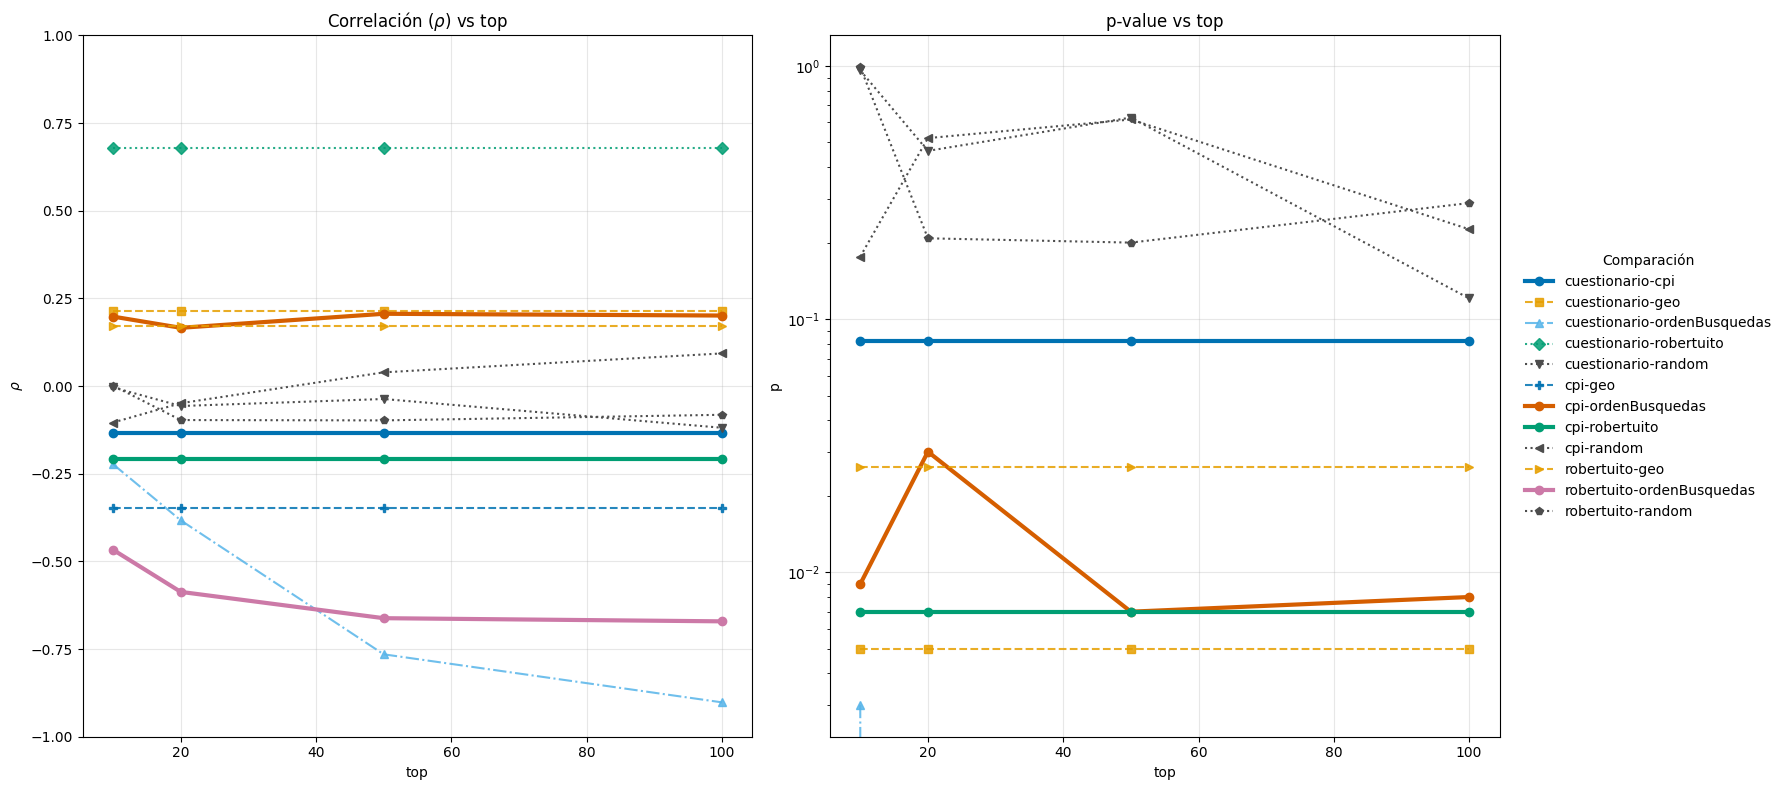

In [ ]:
segmentation = 10

method = "kendall"

all_results = []
for top in [10, 20, 50, 100]:
    # orden de rankings
    corr_dict['ordenBusquedas'], p, _ = srl.results_order_correlation(resultados, all_hrefs, top, method=method, absent_policy="1.5top")
    
    # valoracion de segmentos de rankings
    # formulario
    corr_dict['cuestionario'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['page_info'], segment_size=segmentation, onehot_cols=one_hot_cols)
    # robertuito
    corr_dict['robertuito'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['robertuito'], segment_size=segmentation)

    rand = np.random.rand(n_countries, n_countries)
    rand = (rand + rand.T) / 2  # simétrica
    np.fill_diagonal(rand, 1.0)
    corr_dict['random'] = pd.DataFrame(rand, index=countries, columns=countries)

    # vectorizar matrices (solo triangular superior, sin diagonal)
    vect_dict = {k: srl.upper_tri_vals(corr_dict[k]) for k in corr_dict if k != 'index-index'}

    rp_dict = {}
    titles = []
    # correlación entre evaluación y otras matrices
    for source in ["cuestionario", 'cpi', 'robertuito']:
        rp_dict.update({source+'-'+k: spearmanr(vect_dict[source], vect_dict[k]) for k in vect_dict if k not in [source, 'index-index']})
    
    for d in ['cpi-cuestionario', 'robertuito-cpi', 'robertuito-cuestionario']:
        rp_dict.pop(d) 
    
    results = pd.DataFrame({
        "comparacion": rp_dict.keys(),
        "r": [rp_dict[k][0] for k in rp_dict],
        "p": [rp_dict[k][1] for k in rp_dict],
        "top": top
    })
    results = results.round(3)

    all_results.append(results)

    print("=" * 50)
    print(f"Top {top} resultados:")
    print("-" * 50)
    print(results)
    print("=" * 50+'\n')


# Combinar resultados de todos los tops
df_all = pd.concat(all_results, ignore_index=True)
df_all["comparacion"] = pd.Categorical(df_all["comparacion"], categories=rp_dict.keys())
#print(df_all)
# Pivot para los coeficientes de correlación (r)
wide_r = df_all.pivot(index="top", columns="comparacion", values="r").sort_index()
#print(wide_r)
# Pivot para los p-values
wide_p = df_all.pivot(index="top", columns="comparacion", values="p").sort_index()
#print(wide_p)

cols = wide_r.columns  # o wide_p.columns; idealmente iguales
style_map = srl.build_style_map(cols)

HIGHLIGHT = {
    "cuestionario-cpi",
    "cpi-ordenBusquedas",
    "cpi-robertuito",
    "robertuito-ordenBusquedas",
}

def is_random(lab: str) -> bool:
    return ("-random" in lab) or lab.startswith("random-") or lab.endswith("-random")

# Colores llamativos (puedes cambiarlos)
HIGHLIGHT_COLORS = {
    "cuestionario-cpi": "#0072B2",          # azul
    "cpi-ordenBusquedas": "#D55E00",         # naranja
    "cpi-robertuito": "#009E73",            # verde-azulado
    "robertuito-ordenBusquedas": "#CC79A7", # magenta
}

for lab in cols:
    st = style_map[lab]

    if is_random(lab):
        # más sutil: gris + línea fina + punteada + transparencia
        st["color"] = "0.3"       # gris (0=negro, 1=blanco)
        st["alpha"] = 1
        st["linewidth"] = 1.5
        st["linestyle"] = ":"
        # opcional: quita marcadores
        # st["marker"] = None

    elif lab in HIGHLIGHT:
        # más llamativo: color fijo + línea gruesa + opaco
        st["color"] = HIGHLIGHT_COLORS.get(lab, st["color"])
        st["alpha"] = 1.0
        st["linewidth"] = 3.0
        st["linestyle"] = "-"
        st["marker"] = "o"

    else:
        # resto: intermedio
        st.setdefault("alpha", 0.85)
        st.setdefault("linewidth", 1.5)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Figura para r
ax1 = srl.plot_wide(wide_r, title=r"Correlación ($\rho$) vs top", ylab=r"$\rho$", style_map=style_map, ylim=(-1, 1), ax=axes[0], show_legend=False)

# Figura para p
ax2 = srl.plot_wide(wide_p, title="p-value vs top", ylab="p", style_map=style_map, log_scale=True, ax=axes[1])
plt.show()

# ANALISIS DISTANCIAS

In [11]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

In [12]:
df_index

,cpi,rank,eiu,gi,prs,vdem
country,,,,,,
Argentina,37,99,51.0,32.0,33.0,48.0
Bolivia,28,133,35.0,32.0,33.0,34.0
Chile,63,32,67.0,59.0,60.0,70.0
Colombia,39,92,51.0,46.0,33.0,48.0
Costa Rica,58,42,67.0,59.0,42.0,62.0
Cuba,41,82,51.0,32.0,49.0,35.0
Dominican Republic,36,104,51.0,32.0,24.0,32.0
Ecuador,32,121,35.0,32.0,33.0,30.0
El Salvador,30,130,35.0,32.0,33.0,27.0


In [13]:
X = df_index.copy()

# Asegura numérico y limpia inf
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

# Imputa NaNs con mediana de cada columna
X_imp = X.fillna(X.median(numeric_only=True))

cpi_dist = squareform(pdist(X_imp.values, metric="euclidean"))
corr_dict["cpi_dist"] = pd.DataFrame(cpi_dist, index=X_imp.index, columns=X_imp.index)

# Solo media
## Preguntas binarias

Top 10 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-geo  0.214  0.005   10
1   cuestionario-ordenBusquedas -0.223  0.003   10
2       cuestionario-robertuito  0.680  0.000   10
3           cuestionario-random  0.022  0.778   10
4         cuestionario-cpi_dist -0.058  0.449   10
5                robertuito-geo  0.170  0.026   10
6     robertuito-ordenBusquedas -0.467  0.000   10
7             robertuito-random  0.032  0.682   10
8                  cpi_dist-geo  0.214  0.005   10
9       cpi_dist-ordenBusquedas -0.212  0.005   10
10          cpi_dist-robertuito  0.103  0.182   10
11              cpi_dist-random  0.022  0.776   10

Top 20 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-geo  0.214  0.005   20
1   cuestionario-ordenBusquedas -0.383  0.000   20
2       cuestionario-robertuito  0.680  0.0

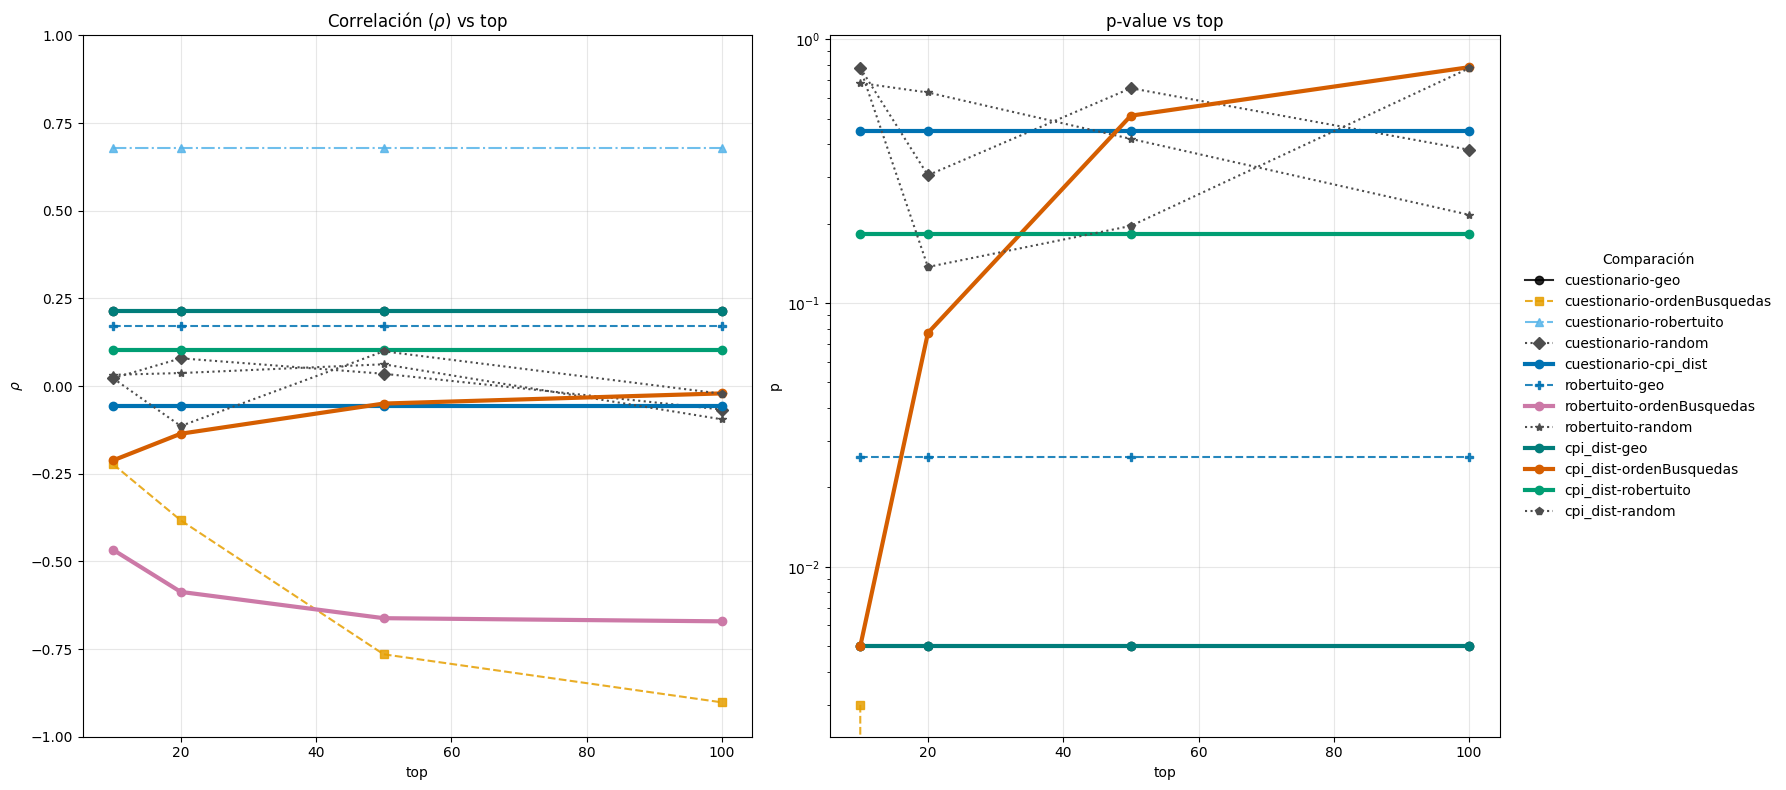

In [18]:
segmentation = 10

method = "kendall"

all_results = []
for top in [10, 20, 50, 100]:
    # orden de rankings
    corr_dict['ordenBusquedas'], p, _ = srl.results_order_correlation(resultados, all_hrefs, top, method=method, absent_policy="1.5top")
    
    # valoracion de segmentos de rankings
    # formulario
    corr_dict['cuestionario'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['page_info'], segment_size=segmentation, onehot_cols=one_hot_cols)
    # robertuito
    corr_dict['robertuito'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['robertuito'], segment_size=segmentation)

    # matrices que usarás
    keys = ["ordenBusquedas", "cuestionario", "robertuito", "cpi_dist", "random"]

    # universo común (intersección)
    common = set(corr_dict["cuestionario"].index)
    for k in keys:
        common &= set(corr_dict[k].index)

    common = sorted(common)

    # reindexa todas al mismo orden/tamaño
    for k in keys:
        corr_dict[k] = corr_dict[k].reindex(index=common, columns=common)

    rand = np.random.rand(len(common), len(common))
    rand = (rand + rand.T) / 2
    np.fill_diagonal(rand, 1.0)
    corr_dict["random"] = pd.DataFrame(rand, index=common, columns=common)


    # vectorizar matrices (solo triangular superior, sin diagonal)
    vect_dict = {k: srl.upper_tri_vals(corr_dict[k]) for k in corr_dict if k not in ['index-index', 'cpi']}

    rp_dict = {}
    titles = []
    # correlación entre evaluación y otras matrices
    for source in ["cuestionario", 'robertuito', 'cpi_dist']:

        rp_dict.update({source+'-'+k: spearmanr(vect_dict[source], vect_dict[k]) for k in vect_dict if k not in [source, 'index-index', 'cpi']})
    
    for d in ['cpi_dist-cuestionario', 'robertuito-cpi_dist', 'robertuito-cuestionario']:
        rp_dict.pop(d) 
    
    results = pd.DataFrame({
        "comparacion": rp_dict.keys(),
        "r": [rp_dict[k][0] for k in rp_dict],
        "p": [rp_dict[k][1] for k in rp_dict],
        "top": top
    })
    results = results.round(3)

    all_results.append(results)

    print("=" * 50)
    print(f"Top {top} resultados:")
    print("-" * 50)
    print(results)
    print("=" * 50+'\n')


# Combinar resultados de todos los tops
df_all = pd.concat(all_results, ignore_index=True)
df_all["comparacion"] = pd.Categorical(df_all["comparacion"], categories=rp_dict.keys())
#print(df_all)
# Pivot para los coeficientes de correlación (r)
wide_r = df_all.pivot(index="top", columns="comparacion", values="r").sort_index()
#print(wide_r)
# Pivot para los p-values
wide_p = df_all.pivot(index="top", columns="comparacion", values="p").sort_index()
#print(wide_p)

cols = wide_r.columns  # o wide_p.columns; idealmente iguales
style_map = srl.build_style_map(cols)

HIGHLIGHT = {
    "cuestionario-cpi_dist",
    "cpi_dist-ordenBusquedas",
    "cpi_dist-robertuito",
    "robertuito-ordenBusquedas",
    "cpi_dist-geo",
}

def is_random(lab: str) -> bool:
    return ("-random" in lab) or lab.startswith("random-") or lab.endswith("-random")

# Colores llamativos (puedes cambiarlos)
HIGHLIGHT_COLORS = {
    "cuestionario-cpi_dist": "#0072B2",          # azul
    "cpi_dist-ordenBusquedas": "#D55E00",         # naranja
    "cpi_dist-robertuito": "#009E73",            # verde-azulado
    "robertuito-ordenBusquedas": "#CC79A7", # magenta
    "cpi_dist-geo": "#017D7A"                    # cian 
}

for lab in cols:
    st = style_map[lab]

    if is_random(lab):
        # más sutil: gris + línea fina + punteada + transparencia
        st["color"] = "0.3"       # gris (0=negro, 1=blanco)
        st["alpha"] = 1
        st["linewidth"] = 1.5
        st["linestyle"] = ":"
        # opcional: quita marcadores
        # st["marker"] = None

    elif lab in HIGHLIGHT:
        # más llamativo: color fijo + línea gruesa + opaco
        st["color"] = HIGHLIGHT_COLORS.get(lab, st["color"])
        st["alpha"] = 1.0
        st["linewidth"] = 3.0
        st["linestyle"] = "-"
        st["marker"] = "o"

    else:
        # resto: intermedio
        st.setdefault("alpha", 0.85)
        st.setdefault("linewidth", 1.5)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Figura para r
ax1 = srl.plot_wide(wide_r, title=r"Correlación ($\rho$) vs top", ylab=r"$\rho$", style_map=style_map, ylim=(-1, 1), ax=axes[0], show_legend=False)

# Figura para p
ax2 = srl.plot_wide(wide_p, title="p-value vs top", ylab="p", style_map=style_map, log_scale=True, ax=axes[1])
plt.show()

## Preguntas ordinales

Wide mean shape: (19, 480), columns: Index(['formalidad__a_mean_s1', 'formalidad__a_mean_s2',
       'formalidad__a_mean_s3', 'formalidad__a_mean_s4',
       'formalidad__a_mean_s5', 'formalidad__a_mean_s6',
       'formalidad__a_mean_s7', 'formalidad__a_mean_s8',
       'formalidad__a_mean_s9', 'formalidad__a_mean_s10',
       ...
       'emociones__h_mean_s1', 'emociones__h_mean_s2', 'emociones__h_mean_s3',
       'emociones__h_mean_s4', 'emociones__h_mean_s5', 'emociones__h_mean_s6',
       'emociones__h_mean_s7', 'emociones__h_mean_s8', 'emociones__h_mean_s9',
       'emociones__h_mean_s10'],
      dtype='object', length=480)
formalidad__a_mean_s1    0
formalidad__a_mean_s2    0
formalidad__a_mean_s3    0
formalidad__a_mean_s4    0
formalidad__a_mean_s5    0
                        ..
emociones__h_mean_s6     0
emociones__h_mean_s7     0
emociones__h_mean_s8     0
emociones__h_mean_s9     0
emociones__h_mean_s10    0
Length: 480, dtype: int64
Wide std shape: (19, 480), columns: Ind

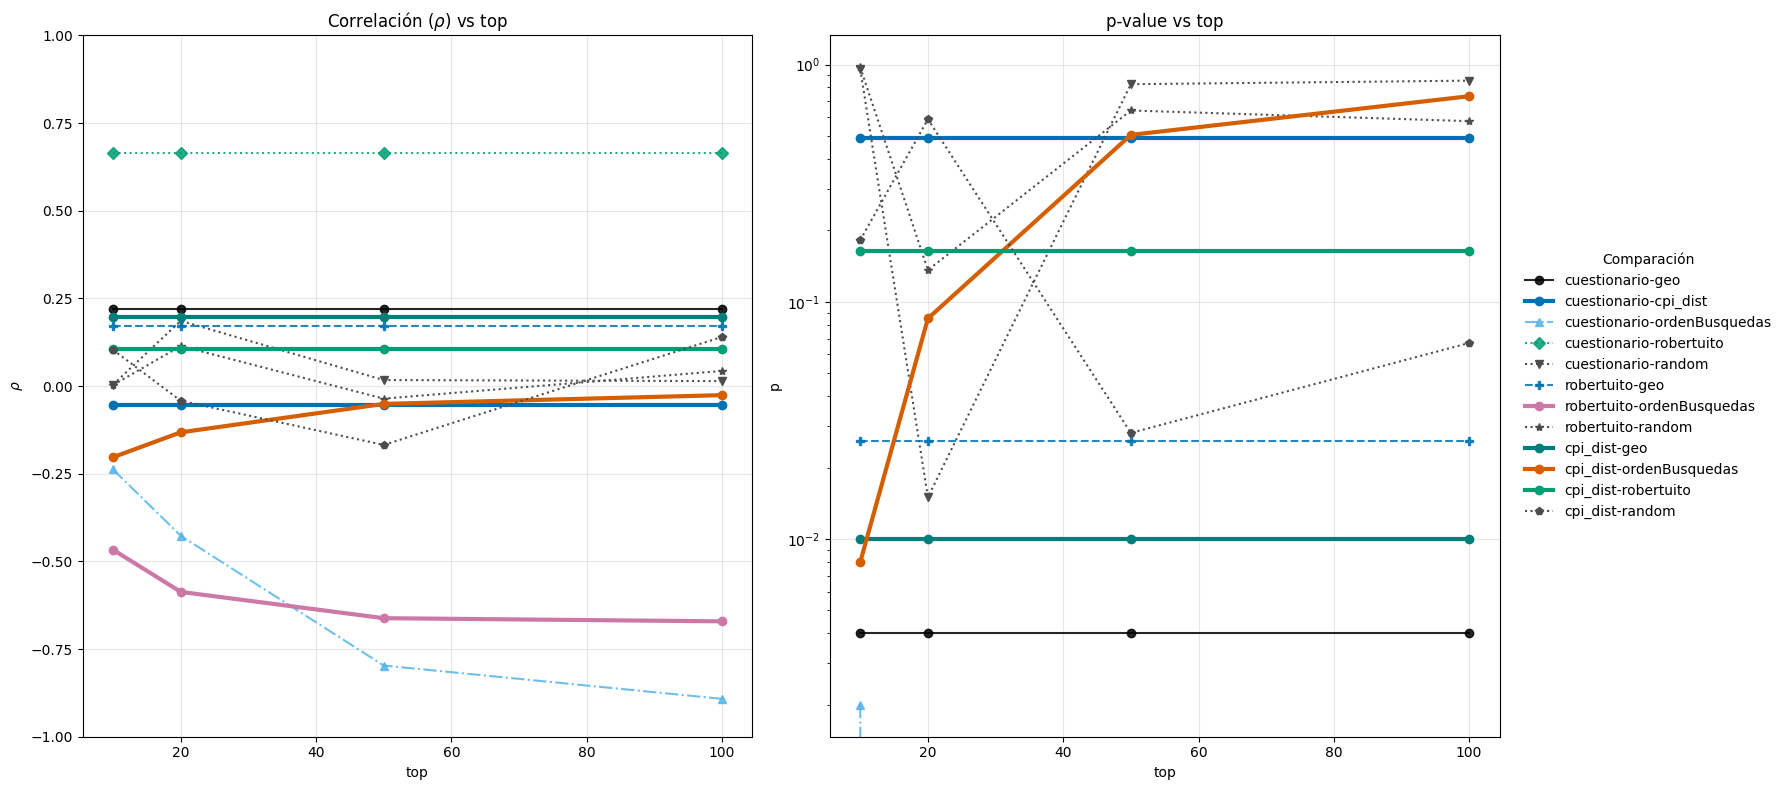

In [14]:
segmentation = 10

method = "kendall"

all_results = []
for top in [10, 20, 50, 100]:
    # orden de rankings
    corr_dict['ordenBusquedas'], p, _ = srl.results_order_correlation(resultados, all_hrefs, top, method=method, absent_policy="1.5top")
    
    # valoracion de segmentos de rankings
    # formulario
    corr_dict['cuestionario'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_pag_info_ordinal, segment_size=segmentation, onehot_cols=one_hot_cols)
    # robertuito
    corr_dict['robertuito'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['robertuito'], segment_size=segmentation)

    # matrices que usarás
    keys = ["ordenBusquedas", "cuestionario", "robertuito", "cpi_dist"]

    # universo común (intersección)
    common = set(corr_dict["cuestionario"].index)
    for k in keys:
        common &= set(corr_dict[k].index)

    common = sorted(common)

    # reindexa todas al mismo orden/tamaño
    for k in keys:
        corr_dict[k] = corr_dict[k].reindex(index=common, columns=common)

    rand = np.random.rand(len(common), len(common))
    rand = (rand + rand.T) / 2
    np.fill_diagonal(rand, 1.0)
    corr_dict["random"] = pd.DataFrame(rand, index=common, columns=common)


    # vectorizar matrices (solo triangular superior, sin diagonal)
    vect_dict = {k: srl.upper_tri_vals(corr_dict[k]) for k in corr_dict if k not in ['index-index', 'cpi']}

    rp_dict = {}
    titles = []
    # correlación entre evaluación y otras matrices
    for source in ["cuestionario", 'robertuito', 'cpi_dist']:

        rp_dict.update({source+'-'+k: spearmanr(vect_dict[source], vect_dict[k]) for k in vect_dict if k not in [source, 'index-index', 'cpi']})
    
    for d in ['cpi_dist-cuestionario', 'robertuito-cpi_dist', 'robertuito-cuestionario']:
        rp_dict.pop(d) 
    
    results = pd.DataFrame({
        "comparacion": rp_dict.keys(),
        "r": [rp_dict[k][0] for k in rp_dict],
        "p": [rp_dict[k][1] for k in rp_dict],
        "top": top
    })
    results = results.round(3)

    all_results.append(results)

    print("=" * 50)
    print(f"Top {top} resultados:")
    print("-" * 50)
    print(results)
    print("=" * 50+'\n')


# Combinar resultados de todos los tops
df_all = pd.concat(all_results, ignore_index=True)
df_all["comparacion"] = pd.Categorical(df_all["comparacion"], categories=rp_dict.keys())
#print(df_all)
# Pivot para los coeficientes de correlación (r)
wide_r = df_all.pivot(index="top", columns="comparacion", values="r").sort_index()
#print(wide_r)
# Pivot para los p-values
wide_p = df_all.pivot(index="top", columns="comparacion", values="p").sort_index()
#print(wide_p)

cols = wide_r.columns  # o wide_p.columns; idealmente iguales
style_map = srl.build_style_map(cols)

HIGHLIGHT = {
    "cuestionario-cpi_dist",
    "cpi_dist-ordenBusquedas",
    "cpi_dist-robertuito",
    "robertuito-ordenBusquedas",
    "cpi_dist-geo",
}

def is_random(lab: str) -> bool:
    return ("-random" in lab) or lab.startswith("random-") or lab.endswith("-random")

# Colores llamativos (puedes cambiarlos)
HIGHLIGHT_COLORS = {
    "cuestionario-cpi_dist": "#0072B2",          # azul
    "cpi_dist-ordenBusquedas": "#D55E00",         # naranja
    "cpi_dist-robertuito": "#009E73",            # verde-azulado
    "robertuito-ordenBusquedas": "#CC79A7", # magenta
    "cpi_dist-geo": "#017D7A"                    # cian 
}

for lab in cols:
    st = style_map[lab]

    if is_random(lab):
        # más sutil: gris + línea fina + punteada + transparencia
        st["color"] = "0.3"       # gris (0=negro, 1=blanco)
        st["alpha"] = 1
        st["linewidth"] = 1.5
        st["linestyle"] = ":"
        # opcional: quita marcadores
        # st["marker"] = None

    elif lab in HIGHLIGHT:
        # más llamativo: color fijo + línea gruesa + opaco
        st["color"] = HIGHLIGHT_COLORS.get(lab, st["color"])
        st["alpha"] = 1.0
        st["linewidth"] = 3.0
        st["linestyle"] = "-"
        st["marker"] = "o"

    else:
        # resto: intermedio
        st.setdefault("alpha", 0.85)
        st.setdefault("linewidth", 1.5)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Figura para r
ax1 = srl.plot_wide(wide_r, title=r"Correlación ($\rho$) vs top", ylab=r"$\rho$", style_map=style_map, ylim=(-1, 1), ax=axes[0], show_legend=False)

# Figura para p
ax2 = srl.plot_wide(wide_p, title="p-value vs top", ylab="p", style_map=style_map, log_scale=True, ax=axes[1])
plt.show()

# Caracteristicas expandidas
## Preguntas binarias

Wide mean shape: (19, 540), columns: Index(['nivel_educacion__a_mean_s1', 'nivel_educacion__a_mean_s2',
       'nivel_educacion__a_mean_s3', 'nivel_educacion__a_mean_s4',
       'nivel_educacion__a_mean_s5', 'nivel_educacion__a_mean_s6',
       'nivel_educacion__a_mean_s7', 'nivel_educacion__a_mean_s8',
       'nivel_educacion__a_mean_s9', 'nivel_educacion__a_mean_s10',
       ...
       'emociones__g_mean_s1', 'emociones__g_mean_s2', 'emociones__g_mean_s3',
       'emociones__g_mean_s4', 'emociones__g_mean_s5', 'emociones__g_mean_s6',
       'emociones__g_mean_s7', 'emociones__g_mean_s8', 'emociones__g_mean_s9',
       'emociones__g_mean_s10'],
      dtype='object', length=540)
nivel_educacion__a_mean_s1    0
nivel_educacion__a_mean_s2    0
nivel_educacion__a_mean_s3    0
nivel_educacion__a_mean_s4    0
nivel_educacion__a_mean_s5    0
                             ..
emociones__g_mean_s6          0
emociones__g_mean_s7          0
emociones__g_mean_s8          0
emociones__g_mean_s9    

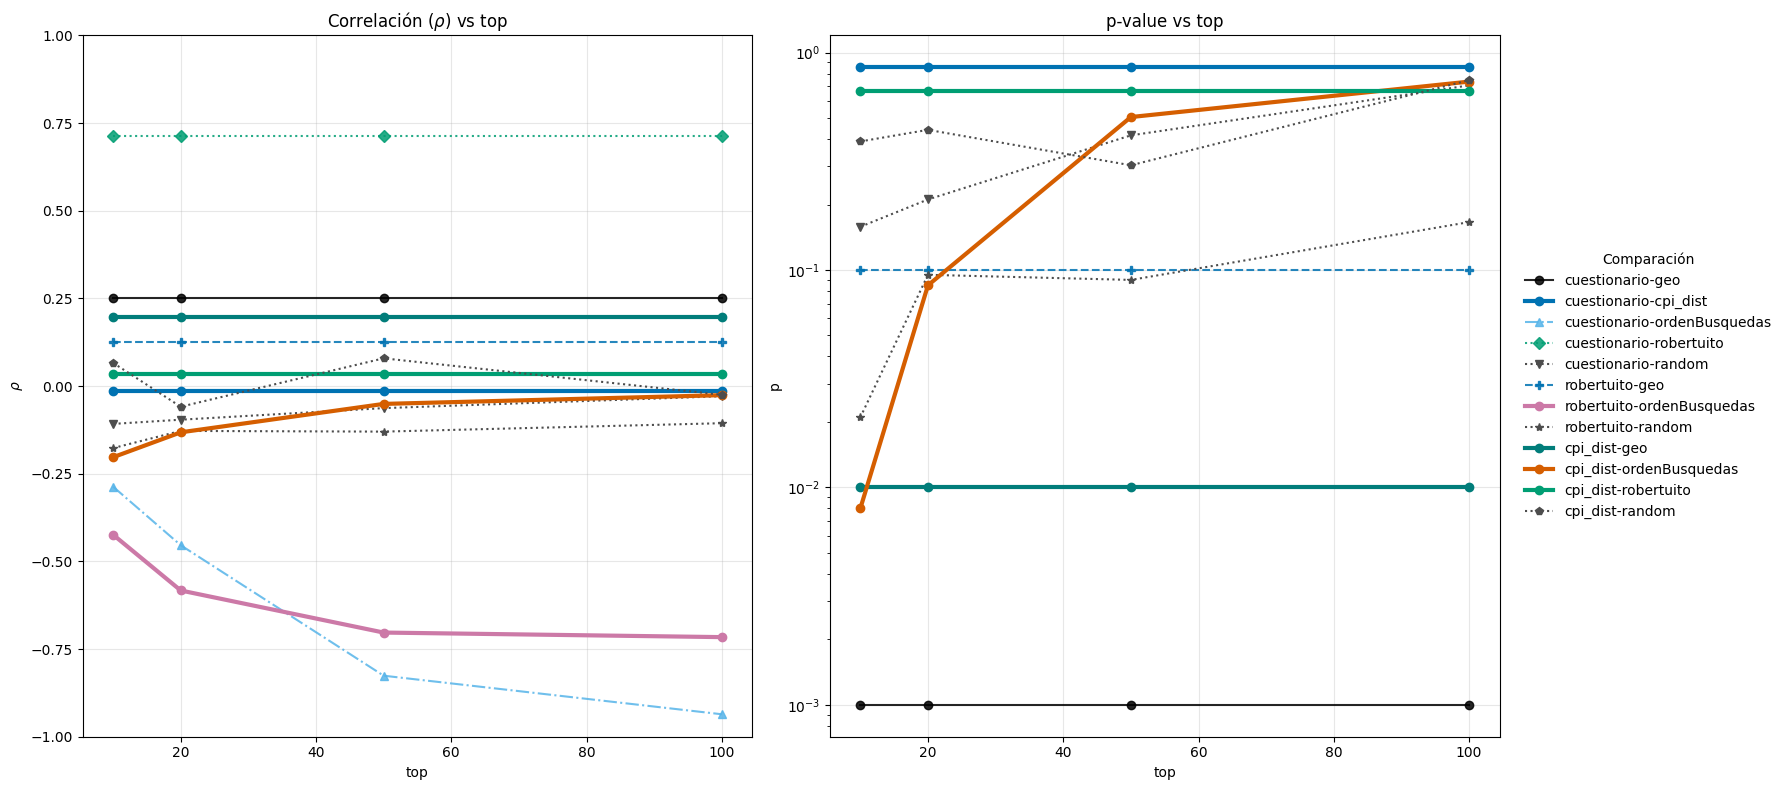

In [15]:
segmentation = 10

method = "kendall"

all_results = []
for top in [10, 20, 50, 100]:
    # orden de rankings
    corr_dict['ordenBusquedas'], p, _ = srl.results_order_correlation(resultados, all_hrefs, top, method=method, absent_policy="1.5top")
    
    # valoracion de segmentos de rankings
    # formulario
    corr_dict['cuestionario'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['page_info'], segment_size=segmentation, onehot_cols=one_hot_cols, expanded=True)
    # robertuito
    corr_dict['robertuito'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['robertuito'], segment_size=segmentation, expanded=True)

    # matrices que usarás
    keys = ["ordenBusquedas", "cuestionario", "robertuito", "cpi_dist", "random"]

    # universo común (intersección)
    common = set(corr_dict["cuestionario"].index)
    for k in keys:
        if k != 'random':
            common &= set(corr_dict[k].index)

    common = sorted(common)

    # reindexa todas al mismo orden/tamaño
    for k in keys:
        if k != 'random':
            corr_dict[k] = corr_dict[k].reindex(index=common, columns=common)

    rand = np.random.rand(len(common), len(common))
    rand = (rand + rand.T) / 2
    np.fill_diagonal(rand, 1.0)
    corr_dict["random"] = pd.DataFrame(rand, index=common, columns=common)


    # vectorizar matrices (solo triangular superior, sin diagonal)
    vect_dict = {k: srl.upper_tri_vals(corr_dict[k]) for k in corr_dict if k not in ['index-index', 'cpi']}

    rp_dict = {}
    titles = []
    # correlación entre evaluación y otras matrices
    for source in ["cuestionario", 'robertuito', 'cpi_dist']:

        rp_dict.update({source+'-'+k: spearmanr(vect_dict[source], vect_dict[k]) for k in vect_dict if k not in [source, 'index-index', 'cpi']})
    
    for d in ['cpi_dist-cuestionario', 'robertuito-cpi_dist', 'robertuito-cuestionario']:
        rp_dict.pop(d) 
    
    results = pd.DataFrame({
        "comparacion": rp_dict.keys(),
        "r": [rp_dict[k][0] for k in rp_dict],
        "p": [rp_dict[k][1] for k in rp_dict],
        "top": top
    })
    results = results.round(3)

    all_results.append(results)

    print("=" * 50)
    print(f"Top {top} resultados:")
    print("-" * 50)
    print(results)
    print("=" * 50+'\n')


# Combinar resultados de todos los tops
df_all = pd.concat(all_results, ignore_index=True)
df_all["comparacion"] = pd.Categorical(df_all["comparacion"], categories=rp_dict.keys())
#print(df_all)
# Pivot para los coeficientes de correlación (r)
wide_r = df_all.pivot(index="top", columns="comparacion", values="r").sort_index()
#print(wide_r)
# Pivot para los p-values
wide_p = df_all.pivot(index="top", columns="comparacion", values="p").sort_index()
#print(wide_p)

cols = wide_r.columns  # o wide_p.columns; idealmente iguales
style_map = srl.build_style_map(cols)

HIGHLIGHT = {
    "cuestionario-cpi_dist",
    "cpi_dist-ordenBusquedas",
    "cpi_dist-robertuito",
    "robertuito-ordenBusquedas",
    "cpi_dist-geo",
}

def is_random(lab: str) -> bool:
    return ("-random" in lab) or lab.startswith("random-") or lab.endswith("-random")

# Colores llamativos (puedes cambiarlos)
HIGHLIGHT_COLORS = {
    "cuestionario-cpi_dist": "#0072B2",          # azul
    "cpi_dist-ordenBusquedas": "#D55E00",         # naranja
    "cpi_dist-robertuito": "#009E73",            # verde-azulado
    "robertuito-ordenBusquedas": "#CC79A7", # magenta
    "cpi_dist-geo": "#017D7A"                    # cian 
}

for lab in cols:
    st = style_map[lab]

    if is_random(lab):
        # más sutil: gris + línea fina + punteada + transparencia
        st["color"] = "0.3"       # gris (0=negro, 1=blanco)
        st["alpha"] = 1
        st["linewidth"] = 1.5
        st["linestyle"] = ":"
        # opcional: quita marcadores
        # st["marker"] = None

    elif lab in HIGHLIGHT:
        # más llamativo: color fijo + línea gruesa + opaco
        st["color"] = HIGHLIGHT_COLORS.get(lab, st["color"])
        st["alpha"] = 1.0
        st["linewidth"] = 3.0
        st["linestyle"] = "-"
        st["marker"] = "o"

    else:
        # resto: intermedio
        st.setdefault("alpha", 0.85)
        st.setdefault("linewidth", 1.5)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Figura para r
ax1 = srl.plot_wide(wide_r, title=r"Correlación ($\rho$) vs top", ylab=r"$\rho$", style_map=style_map, ylim=(-1, 1), ax=axes[0], show_legend=False)

# Figura para p
ax2 = srl.plot_wide(wide_p, title="p-value vs top", ylab="p", style_map=style_map, log_scale=True, ax=axes[1])
plt.show()

## Ordinales

Wide mean shape: (19, 480), columns: Index(['formalidad__a_mean_s1', 'formalidad__a_mean_s2',
       'formalidad__a_mean_s3', 'formalidad__a_mean_s4',
       'formalidad__a_mean_s5', 'formalidad__a_mean_s6',
       'formalidad__a_mean_s7', 'formalidad__a_mean_s8',
       'formalidad__a_mean_s9', 'formalidad__a_mean_s10',
       ...
       'emociones__h_mean_s1', 'emociones__h_mean_s2', 'emociones__h_mean_s3',
       'emociones__h_mean_s4', 'emociones__h_mean_s5', 'emociones__h_mean_s6',
       'emociones__h_mean_s7', 'emociones__h_mean_s8', 'emociones__h_mean_s9',
       'emociones__h_mean_s10'],
      dtype='object', length=480)
formalidad__a_mean_s1    0
formalidad__a_mean_s2    0
formalidad__a_mean_s3    0
formalidad__a_mean_s4    0
formalidad__a_mean_s5    0
                        ..
emociones__h_mean_s6     0
emociones__h_mean_s7     0
emociones__h_mean_s8     0
emociones__h_mean_s9     0
emociones__h_mean_s10    0
Length: 480, dtype: int64
Wide std shape: (19, 480), columns: Ind

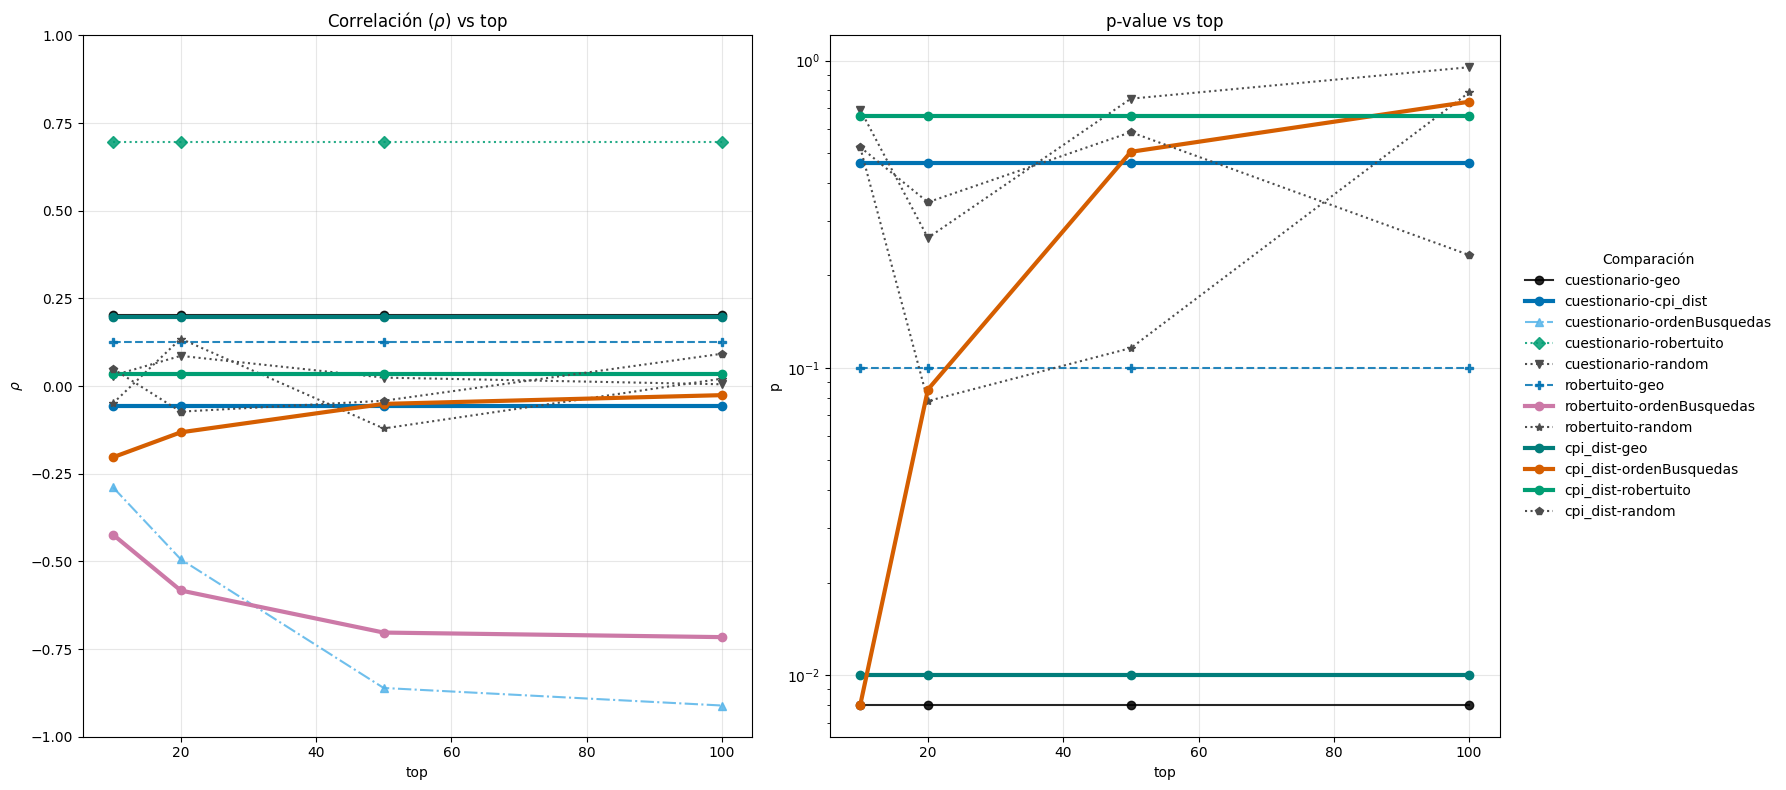

In [18]:
segmentation = 10

method = "kendall"

all_results = []
for top in [10, 20, 50, 100]:
    # orden de rankings
    corr_dict['ordenBusquedas'], p, _ = srl.results_order_correlation(resultados, all_hrefs, top, method=method, absent_policy="1.5top")
    
    # valoracion de segmentos de rankings
    # formulario
    corr_dict['cuestionario'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_pag_info_ordinal, segment_size=segmentation, onehot_cols=one_hot_cols, expanded=True)
    # robertuito
    corr_dict['robertuito'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['robertuito'], segment_size=segmentation, expanded=True)

    # matrices que usarás
    keys = ["ordenBusquedas", "cuestionario", "robertuito", "cpi_dist"]

    # universo común (intersección)
    common = set(corr_dict["cuestionario"].index)
    for k in keys:
        common &= set(corr_dict[k].index)

    common = sorted(common)

    # reindexa todas al mismo orden/tamaño
    for k in keys:
        corr_dict[k] = corr_dict[k].reindex(index=common, columns=common)

    rand = np.random.rand(len(common), len(common))
    rand = (rand + rand.T) / 2
    np.fill_diagonal(rand, 1.0)
    corr_dict["random"] = pd.DataFrame(rand, index=common, columns=common)


    # vectorizar matrices (solo triangular superior, sin diagonal)
    vect_dict = {k: srl.upper_tri_vals(corr_dict[k]) for k in corr_dict if k not in ['index-index', 'cpi']}

    rp_dict = {}
    titles = []
    # correlación entre evaluación y otras matrices
    for source in ["cuestionario", 'robertuito', 'cpi_dist']:

        rp_dict.update({source+'-'+k: spearmanr(vect_dict[source], vect_dict[k]) for k in vect_dict if k not in [source, 'index-index', 'cpi']})
    
    for d in ['cpi_dist-cuestionario', 'robertuito-cpi_dist', 'robertuito-cuestionario']:
        rp_dict.pop(d) 
    
    results = pd.DataFrame({
        "comparacion": rp_dict.keys(),
        "r": [rp_dict[k][0] for k in rp_dict],
        "p": [rp_dict[k][1] for k in rp_dict],
        "top": top
    })
    results = results.round(3)

    all_results.append(results)

    print("=" * 50)
    print(f"Top {top} resultados:")
    print("-" * 50)
    print(results)
    print("=" * 50+'\n')


# Combinar resultados de todos los tops
df_all = pd.concat(all_results, ignore_index=True)
df_all["comparacion"] = pd.Categorical(df_all["comparacion"], categories=rp_dict.keys())
#print(df_all)
# Pivot para los coeficientes de correlación (r)
wide_r = df_all.pivot(index="top", columns="comparacion", values="r").sort_index()
#print(wide_r)
# Pivot para los p-values
wide_p = df_all.pivot(index="top", columns="comparacion", values="p").sort_index()
#print(wide_p)

cols = wide_r.columns  # o wide_p.columns; idealmente iguales
style_map = srl.build_style_map(cols)

HIGHLIGHT = {
    "cuestionario-cpi_dist",
    "cpi_dist-ordenBusquedas",
    "cpi_dist-robertuito",
    "robertuito-ordenBusquedas",
    "cpi_dist-geo",
}

def is_random(lab: str) -> bool:
    return ("-random" in lab) or lab.startswith("random-") or lab.endswith("-random")

# Colores llamativos (puedes cambiarlos)
HIGHLIGHT_COLORS = {
    "cuestionario-cpi_dist": "#0072B2",          # azul
    "cpi_dist-ordenBusquedas": "#D55E00",         # naranja
    "cpi_dist-robertuito": "#009E73",            # verde-azulado
    "robertuito-ordenBusquedas": "#CC79A7", # magenta
    "cpi_dist-geo": "#017D7A"                    # cian 
}

for lab in cols:
    st = style_map[lab]

    if is_random(lab):
        # más sutil: gris + línea fina + punteada + transparencia
        st["color"] = "0.3"       # gris (0=negro, 1=blanco)
        st["alpha"] = 1
        st["linewidth"] = 1.5
        st["linestyle"] = ":"
        # opcional: quita marcadores
        # st["marker"] = None

    elif lab in HIGHLIGHT:
        # más llamativo: color fijo + línea gruesa + opaco
        st["color"] = HIGHLIGHT_COLORS.get(lab, st["color"])
        st["alpha"] = 1.0
        st["linewidth"] = 3.0
        st["linestyle"] = "-"
        st["marker"] = "o"

    else:
        # resto: intermedio
        st.setdefault("alpha", 0.85)
        st.setdefault("linewidth", 1.5)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Figura para r
ax1 = srl.plot_wide(wide_r, title=r"Correlación ($\rho$) vs top", ylab=r"$\rho$", style_map=style_map, ylim=(-1, 1), ax=axes[0], show_legend=False)

# Figura para p
ax2 = srl.plot_wide(wide_p, title="p-value vs top", ylab="p", style_map=style_map, log_scale=True, ax=axes[1])
plt.show()

# CORRELACION MATRIZ-MATRIZ

Top 10 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-cpi -0.133  0.492   10
1              cuestionario-geo  0.214  0.166   10
2   cuestionario-ordenBusquedas -0.223  0.237   10
3       cuestionario-robertuito  0.680  0.000   10
4           cuestionario-random  0.078  0.306   10
5         cuestionario-cpi_dist -0.058  0.720   10
6                       cpi-geo -0.348  0.019   10
7            cpi-ordenBusquedas  0.198  0.249   10
8                cpi-robertuito -0.207  0.216   10
9                    cpi-random -0.248  0.000   10
10                 cpi-cpi_dist -0.773  0.000   10
11               robertuito-geo  0.170  0.222   10
12    robertuito-ordenBusquedas -0.467  0.004   10
13            robertuito-random  0.067  0.383   10
14          robertuito-cpi_dist  0.103  0.459   10
15                 cpi_dist-geo  0.214  0.063   10
16      cpi_dist-ordenBusquedas -0.212  0.118   10
17          

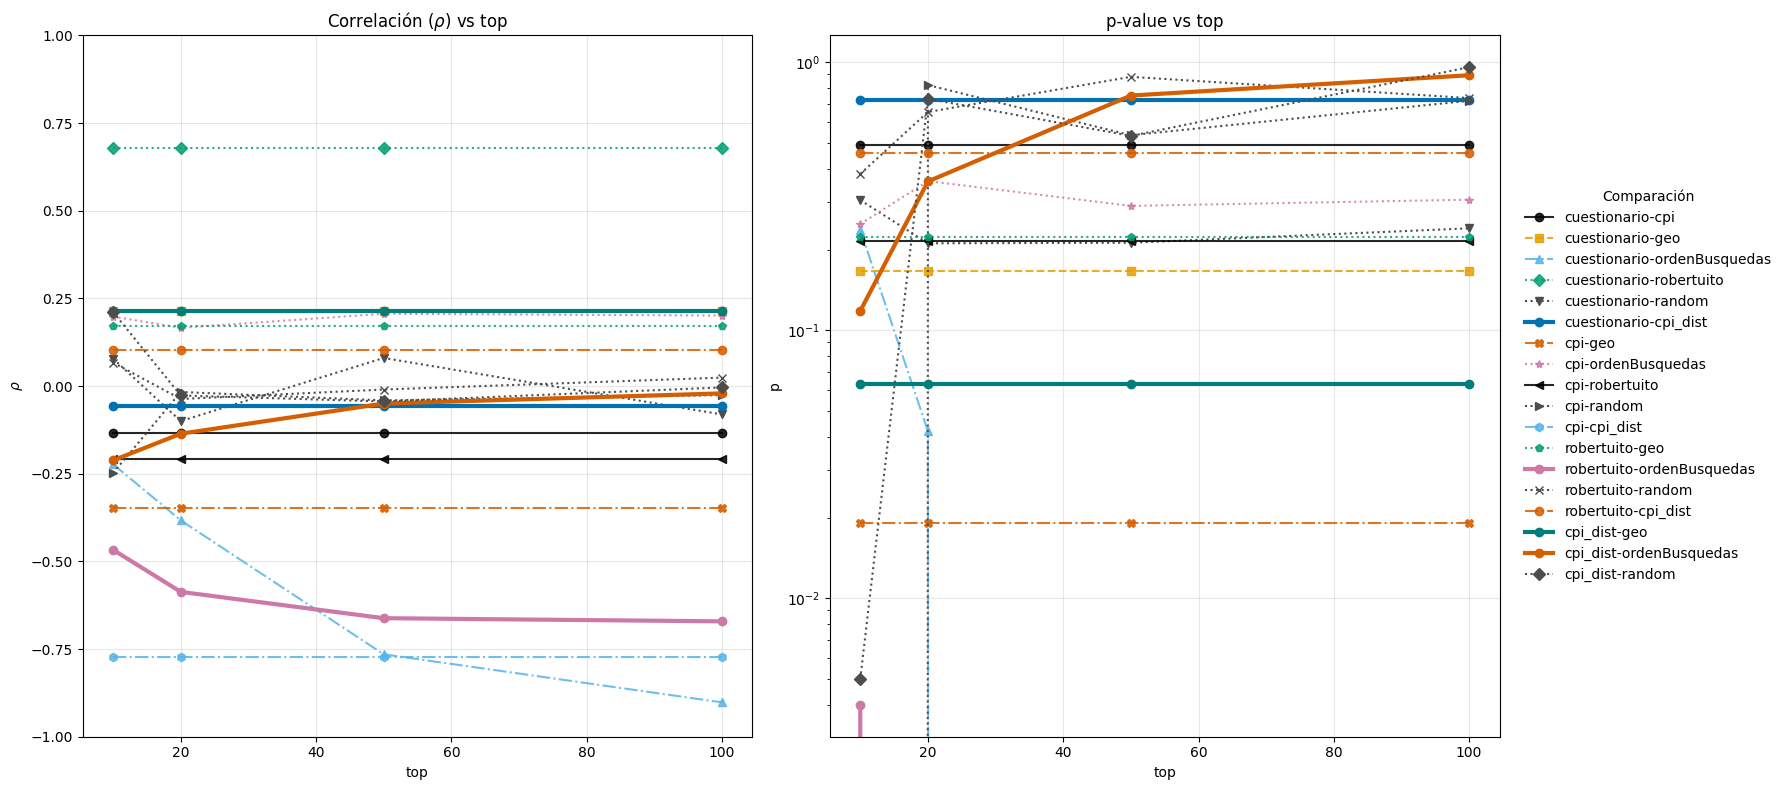

In [19]:
segmentation = 10

method = "kendall"

all_results = []
for top in [10, 20, 50, 100]:
    # orden de rankings
    corr_dict['ordenBusquedas'], p, _ = srl.results_order_correlation(resultados, all_hrefs, top, method=method, absent_policy="1.5top")
    
    # valoracion de segmentos de rankings
    # formulario
    corr_dict['cuestionario'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['page_info'], segment_size=segmentation, onehot_cols=one_hot_cols)
    # robertuito
    corr_dict['robertuito'], _ = srl.compute_rank_feature_distance(df_dict['rankings'], df_dict['robertuito'], segment_size=segmentation)

    # matrices que usarás
    keys = ["ordenBusquedas", "cuestionario", "robertuito", "cpi_dist", "random"]

    # universo común (intersección)
    common = set(corr_dict["cuestionario"].index)
    for k in keys:
        common &= set(corr_dict[k].index)

    common = sorted(common)

    # reindexa todas al mismo orden/tamaño
    for k in keys:
        corr_dict[k] = corr_dict[k].reindex(index=common, columns=common)

    rand = np.random.rand(len(common), len(common))
    rand = (rand + rand.T) / 2
    np.fill_diagonal(rand, 1.0)
    corr_dict["random"] = pd.DataFrame(rand, index=common, columns=common)

    rp_dict = {}
    titles = []
    # correlación entre evaluación y otras matrices
    for source in ["cuestionario", 'cpi', 'robertuito', 'cpi_dist']:
        rp_dict.update({source+'-'+k: srl.mantel_spearman(corr_dict[source], corr_dict[k]) for k in corr_dict if k not in ['index-index', source]})
    
    for d in ['cpi-cuestionario', 'robertuito-cpi', 'robertuito-cuestionario', 'cpi_dist-cuestionario', 'cpi_dist-cpi', 'cpi_dist-robertuito']:
        rp_dict.pop(d) 
    
    results = pd.DataFrame({
        "comparacion": rp_dict.keys(),
        "r": [rp_dict[k][0] for k in rp_dict],
        "p": [rp_dict[k][1] for k in rp_dict],
        "top": top
    })
    results = results.round(3)

    all_results.append(results)

    print("=" * 50)
    print(f"Top {top} resultados:")
    print("-" * 50)
    print(results)
    print("=" * 50+'\n')


# Combinar resultados de todos los tops
df_all = pd.concat(all_results, ignore_index=True)
df_all["comparacion"] = pd.Categorical(df_all["comparacion"], categories=rp_dict.keys())
#print(df_all)
# Pivot para los coeficientes de correlación (r)
wide_r = df_all.pivot(index="top", columns="comparacion", values="r").sort_index()
#print(wide_r)
# Pivot para los p-values
wide_p = df_all.pivot(index="top", columns="comparacion", values="p").sort_index()
#print(wide_p)

cols = wide_r.columns  # o wide_p.columns; idealmente iguales
style_map = srl.build_style_map(cols)

HIGHLIGHT = {
    "cuestionario-cpi_dist",
    "cpi_dist-ordenBusquedas",
    "cpi_dist-robertuito",
    "robertuito-ordenBusquedas",
    "cpi_dist-geo",
}

def is_random(lab: str) -> bool:
    return ("-random" in lab) or lab.startswith("random-") or lab.endswith("-random")

# Colores llamativos (puedes cambiarlos)
HIGHLIGHT_COLORS = {
    "cuestionario-cpi_dist": "#0072B2",          # azul
    "cpi_dist-ordenBusquedas": "#D55E00",         # naranja
    "cpi_dist-robertuito": "#009E73",            # verde-azulado
    "robertuito-ordenBusquedas": "#CC79A7", # magenta
    "cpi_dist-geo": "#017D7A"                    # cian 
}

for lab in cols:
    st = style_map[lab]

    if is_random(lab):
        # más sutil: gris + línea fina + punteada + transparencia
        st["color"] = "0.3"       # gris (0=negro, 1=blanco)
        st["alpha"] = 1
        st["linewidth"] = 1.5
        st["linestyle"] = ":"
        # opcional: quita marcadores
        # st["marker"] = None

    elif lab in HIGHLIGHT:
        # más llamativo: color fijo + línea gruesa + opaco
        st["color"] = HIGHLIGHT_COLORS.get(lab, st["color"])
        st["alpha"] = 1.0
        st["linewidth"] = 3.0
        st["linestyle"] = "-"
        st["marker"] = "o"

    else:
        # resto: intermedio
        st.setdefault("alpha", 0.85)
        st.setdefault("linewidth", 1.5)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Figura para r
ax1 = srl.plot_wide(wide_r, title=r"Correlación ($\rho$) vs top", ylab=r"$\rho$", style_map=style_map, ylim=(-1, 1), ax=axes[0], show_legend=False)

# Figura para p
ax2 = srl.plot_wide(wide_p, title="p-value vs top", ylab="p", style_map=style_map, log_scale=True, ax=axes[1])
plt.show()

# PROMEDIO PONDERADO
## Inverse log

Top 10 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-cpi -0.113  0.143   10
1              cuestionario-geo  0.208  0.006   10
2   cuestionario-ordenBusquedas -0.270  0.000   10
3       cuestionario-robertuito  0.578  0.000   10
4           cuestionario-random  0.093  0.226   10
5                       cpi-geo -0.315  0.000   10
6            cpi-ordenBusquedas  0.194  0.011   10
7                cpi-robertuito -0.106  0.166   10
8                    cpi-random -0.007  0.929   10
9                robertuito-geo  0.046  0.549   10
10    robertuito-ordenBusquedas -0.203  0.008   10
11            robertuito-random  0.043  0.576   10

Top 20 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-cpi -0.113  0.143   20
1              cuestionario-geo  0.208  0.006   20
2   cuestionario-ordenBusquedas -0.430  0.0

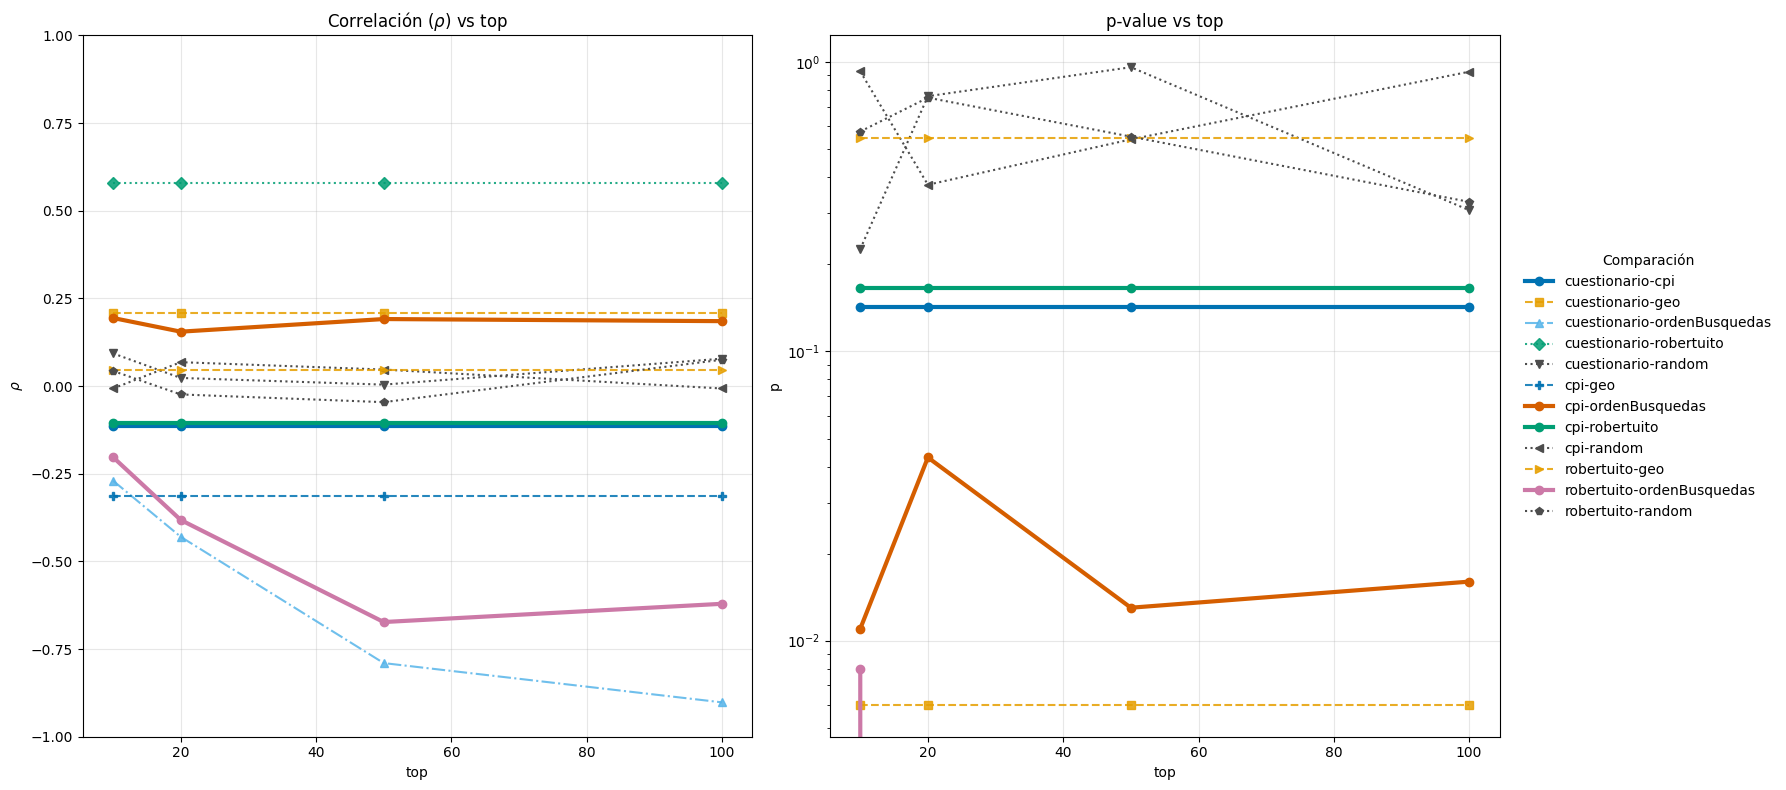

In [10]:
df_dict = {
    "cpi": df_index,
    "rankings": df_rankings,
    "page_info": df_pag_info,
    "robertuito": df_robertuito
}

method = "kendall"

all_results = []
for top in [10, 20, 50, 100]:
    # orden de rankings
    corr_dict['ordenBusquedas'], p, _ = srl.results_order_correlation(resultados, all_hrefs, top, method=method, absent_policy="1.5top")
    
    # valoracion de segmentos de rankings
    # formulario
    corr_dict['cuestionario'], _ = srl.compute_rank_feature_ponderate(df_dict['rankings'], df_dict['page_info'])
    # robertuito
    corr_dict['robertuito'], _ = srl.compute_rank_feature_ponderate(df_dict['rankings'], df_dict['robertuito'])

    rand = np.random.rand(n_countries, n_countries)
    rand = (rand + rand.T) / 2  # simétrica
    np.fill_diagonal(rand, 1.0)
    corr_dict['random'] = pd.DataFrame(rand, index=countries, columns=countries)

    # vectorizar matrices (solo triangular superior, sin diagonal)
    vect_dict = {k: srl.upper_tri_vals(corr_dict[k]) for k in corr_dict if k != 'index-index'}

    rp_dict = {}
    titles = []
    # correlación entre evaluación y otras matrices
    for source in ["cuestionario", 'cpi', 'robertuito']:
        rp_dict.update({source+'-'+k: spearmanr(vect_dict[source], vect_dict[k]) for k in vect_dict if k not in [source, 'index-index']})
    
    for d in ['cpi-cuestionario', 'robertuito-cpi', 'robertuito-cuestionario']:
        rp_dict.pop(d) 
    
    results = pd.DataFrame({
        "comparacion": rp_dict.keys(),
        "r": [rp_dict[k][0] for k in rp_dict],
        "p": [rp_dict[k][1] for k in rp_dict],
        "top": top
    })
    results = results.round(3)

    all_results.append(results)

    print("=" * 50)
    print(f"Top {top} resultados:")
    print("-" * 50)
    print(results)
    print("=" * 50+'\n')


# Combinar resultados de todos los tops
df_all = pd.concat(all_results, ignore_index=True)
df_all["comparacion"] = pd.Categorical(df_all["comparacion"], categories=rp_dict.keys())
#print(df_all)
# Pivot para los coeficientes de correlación (r)
wide_r = df_all.pivot(index="top", columns="comparacion", values="r").sort_index()
#print(wide_r)
# Pivot para los p-values
wide_p = df_all.pivot(index="top", columns="comparacion", values="p").sort_index()
#print(wide_p)

cols = wide_r.columns  # o wide_p.columns; idealmente iguales
style_map = srl.build_style_map(cols)

HIGHLIGHT = {
    "cuestionario-cpi",
    "cpi-ordenBusquedas",
    "cpi-robertuito",
    "robertuito-ordenBusquedas",
}

def is_random(lab: str) -> bool:
    return ("-random" in lab) or lab.startswith("random-") or lab.endswith("-random")

# Colores llamativos (puedes cambiarlos)
HIGHLIGHT_COLORS = {
    "cuestionario-cpi": "#0072B2",          # azul
    "cpi-ordenBusquedas": "#D55E00",         # naranja
    "cpi-robertuito": "#009E73",            # verde-azulado
    "robertuito-ordenBusquedas": "#CC79A7", # magenta
}

for lab in cols:
    st = style_map[lab]

    if is_random(lab):
        # más sutil: gris + línea fina + punteada + transparencia
        st["color"] = "0.3"       # gris (0=negro, 1=blanco)
        st["alpha"] = 1
        st["linewidth"] = 1.5
        st["linestyle"] = ":"
        # opcional: quita marcadores
        # st["marker"] = None

    elif lab in HIGHLIGHT:
        # más llamativo: color fijo + línea gruesa + opaco
        st["color"] = HIGHLIGHT_COLORS.get(lab, st["color"])
        st["alpha"] = 1.0
        st["linewidth"] = 3.0
        st["linestyle"] = "-"
        st["marker"] = "o"

    else:
        # resto: intermedio
        st.setdefault("alpha", 0.85)
        st.setdefault("linewidth", 1.5)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Figura para r
ax1 = srl.plot_wide(wide_r, title=r"Correlación ($\rho$) vs top", ylab=r"$\rho$", style_map=style_map, ylim=(-1, 1), ax=axes[0], show_legend=False)

# Figura para p
ax2 = srl.plot_wide(wide_p, title="p-value vs top", ylab="p", style_map=style_map, log_scale=True, ax=axes[1])
plt.show()

## Inverse rank

Top 10 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-cpi -0.183  0.017   10
1              cuestionario-geo  0.249  0.001   10
2   cuestionario-ordenBusquedas -0.574  0.000   10
3       cuestionario-robertuito  0.424  0.000   10
4           cuestionario-random  0.049  0.524   10
5                       cpi-geo -0.315  0.000   10
6            cpi-ordenBusquedas  0.194  0.011   10
7                cpi-robertuito -0.257  0.001   10
8                    cpi-random  0.103  0.179   10
9                robertuito-geo  0.058  0.455   10
10    robertuito-ordenBusquedas -0.447  0.000   10
11            robertuito-random  0.030  0.701   10

Top 20 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-cpi -0.183  0.017   20
1              cuestionario-geo  0.249  0.001   20
2   cuestionario-ordenBusquedas -0.650  0.0

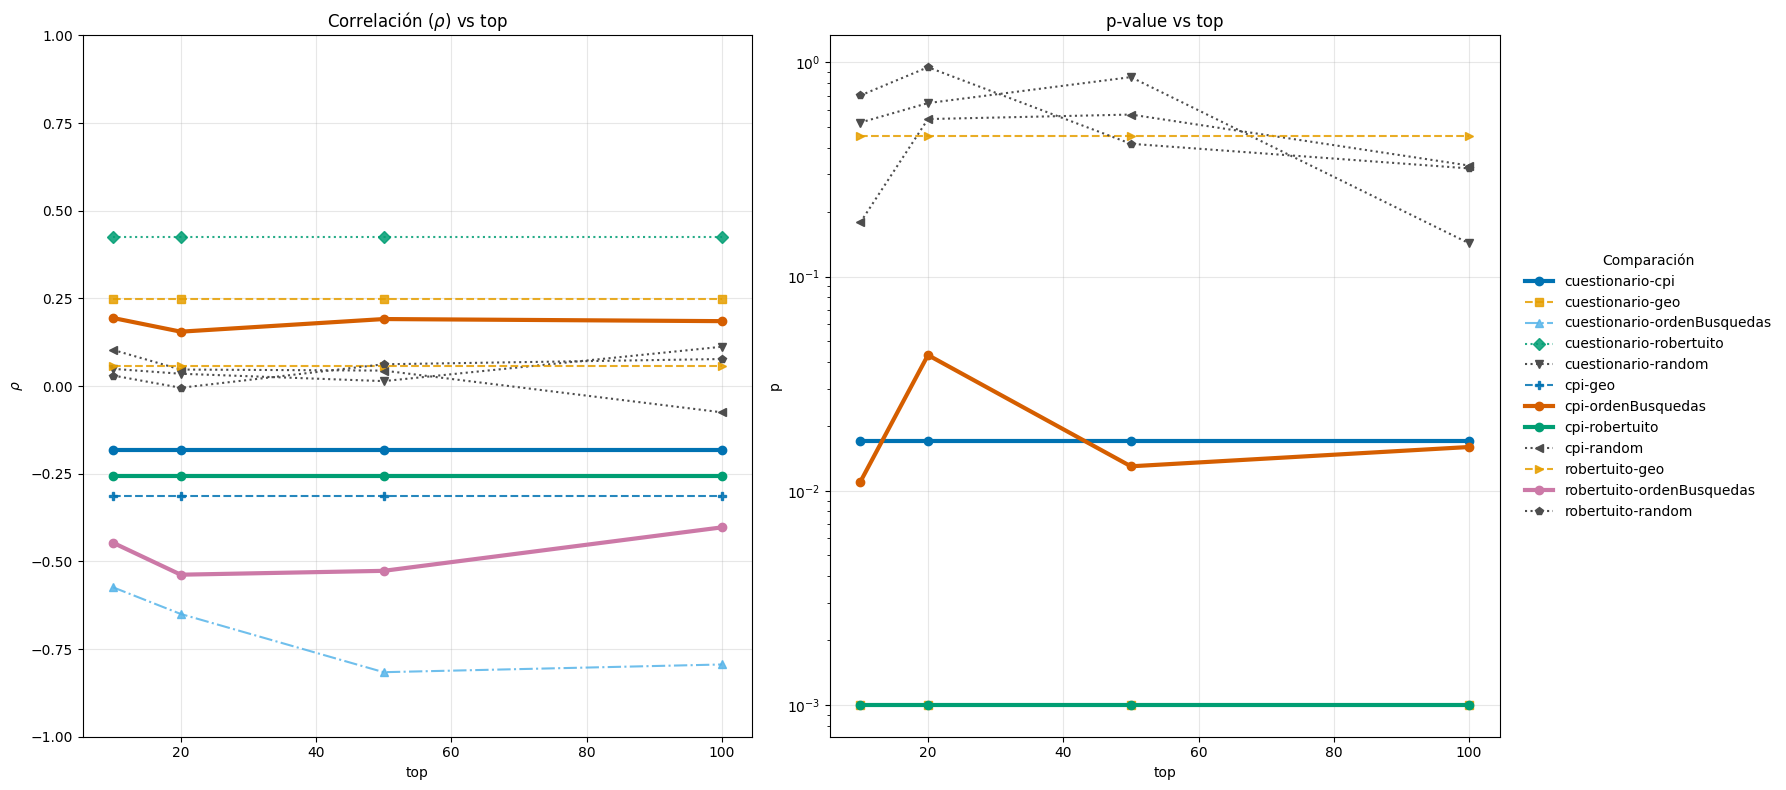

In [13]:
df_dict = {
    "cpi": df_index,
    "rankings": df_rankings,
    "page_info": df_pag_info,
    "robertuito": df_robertuito
}

method = "kendall"

all_results = []
for top in [10, 20, 50, 100]:
    # orden de rankings
    corr_dict['ordenBusquedas'], p, _ = srl.results_order_correlation(resultados, all_hrefs, top, method=method, absent_policy="1.5top")
    
    # valoracion de segmentos de rankings
    # formulario
    corr_dict['cuestionario'], _ = srl.compute_rank_feature_ponderate(df_dict['rankings'], df_dict['page_info'], weight_func=srl.inverse_rank_weight)
    # robertuito
    corr_dict['robertuito'], _ = srl.compute_rank_feature_ponderate(df_dict['rankings'], df_dict['robertuito'], weight_func=srl.inverse_rank_weight)

    rand = np.random.rand(n_countries, n_countries)
    rand = (rand + rand.T) / 2  # simétrica
    np.fill_diagonal(rand, 1.0)
    corr_dict['random'] = pd.DataFrame(rand, index=countries, columns=countries)

    # vectorizar matrices (solo triangular superior, sin diagonal)
    vect_dict = {k: srl.upper_tri_vals(corr_dict[k]) for k in corr_dict if k != 'index-index'}

    rp_dict = {}
    titles = []
    # correlación entre evaluación y otras matrices
    for source in ["cuestionario", 'cpi', 'robertuito']:
        rp_dict.update({source+'-'+k: spearmanr(vect_dict[source], vect_dict[k]) for k in vect_dict if k not in [source, 'index-index']})
    
    for d in ['cpi-cuestionario', 'robertuito-cpi', 'robertuito-cuestionario']:
        rp_dict.pop(d) 
    
    results = pd.DataFrame({
        "comparacion": rp_dict.keys(),
        "r": [rp_dict[k][0] for k in rp_dict],
        "p": [rp_dict[k][1] for k in rp_dict],
        "top": top
    })
    results = results.round(3)

    all_results.append(results)

    print("=" * 50)
    print(f"Top {top} resultados:")
    print("-" * 50)
    print(results)
    print("=" * 50+'\n')


# Combinar resultados de todos los tops
df_all = pd.concat(all_results, ignore_index=True)
df_all["comparacion"] = pd.Categorical(df_all["comparacion"], categories=rp_dict.keys())
#print(df_all)
# Pivot para los coeficientes de correlación (r)
wide_r = df_all.pivot(index="top", columns="comparacion", values="r").sort_index()
#print(wide_r)
# Pivot para los p-values
wide_p = df_all.pivot(index="top", columns="comparacion", values="p").sort_index()
#print(wide_p)

cols = wide_r.columns  # o wide_p.columns; idealmente iguales
style_map = srl.build_style_map(cols)

HIGHLIGHT = {
    "cuestionario-cpi",
    "cpi-ordenBusquedas",
    "cpi-robertuito",
    "robertuito-ordenBusquedas",
}

def is_random(lab: str) -> bool:
    return ("-random" in lab) or lab.startswith("random-") or lab.endswith("-random")

# Colores llamativos (puedes cambiarlos)
HIGHLIGHT_COLORS = {
    "cuestionario-cpi": "#0072B2",          # azul
    "cpi-ordenBusquedas": "#D55E00",         # naranja
    "cpi-robertuito": "#009E73",            # verde-azulado
    "robertuito-ordenBusquedas": "#CC79A7", # magenta
}

for lab in cols:
    st = style_map[lab]

    if is_random(lab):
        # más sutil: gris + línea fina + punteada + transparencia
        st["color"] = "0.3"       # gris (0=negro, 1=blanco)
        st["alpha"] = 1
        st["linewidth"] = 1.5
        st["linestyle"] = ":"
        # opcional: quita marcadores
        # st["marker"] = None

    elif lab in HIGHLIGHT:
        # más llamativo: color fijo + línea gruesa + opaco
        st["color"] = HIGHLIGHT_COLORS.get(lab, st["color"])
        st["alpha"] = 1.0
        st["linewidth"] = 3.0
        st["linestyle"] = "-"
        st["marker"] = "o"

    else:
        # resto: intermedio
        st.setdefault("alpha", 0.85)
        st.setdefault("linewidth", 1.5)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Figura para r
ax1 = srl.plot_wide(wide_r, title=r"Correlación ($\rho$) vs top", ylab=r"$\rho$", style_map=style_map, ylim=(-1, 1), ax=axes[0], show_legend=False)

# Figura para p
ax2 = srl.plot_wide(wide_p, title="p-value vs top", ylab="p", style_map=style_map, log_scale=True, ax=axes[1])
plt.show()

Top 10 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-cpi -0.016  0.836   10
1              cuestionario-geo  0.211  0.006   10
2   cuestionario-ordenBusquedas -0.488  0.000   10
3       cuestionario-robertuito  0.423  0.000   10
4           cuestionario-random -0.097  0.209   10
5                       cpi-geo -0.315  0.000   10
6            cpi-ordenBusquedas  0.194  0.011   10
7                cpi-robertuito -0.017  0.824   10
8                    cpi-random  0.048  0.535   10
9                robertuito-geo  0.116  0.131   10
10    robertuito-ordenBusquedas -0.201  0.009   10
11            robertuito-random -0.139  0.069   10

Top 20 resultados:
--------------------------------------------------
                    comparacion      r      p  top
0              cuestionario-cpi -0.016  0.836   20
1              cuestionario-geo  0.211  0.006   20
2   cuestionario-ordenBusquedas -0.563  0.0

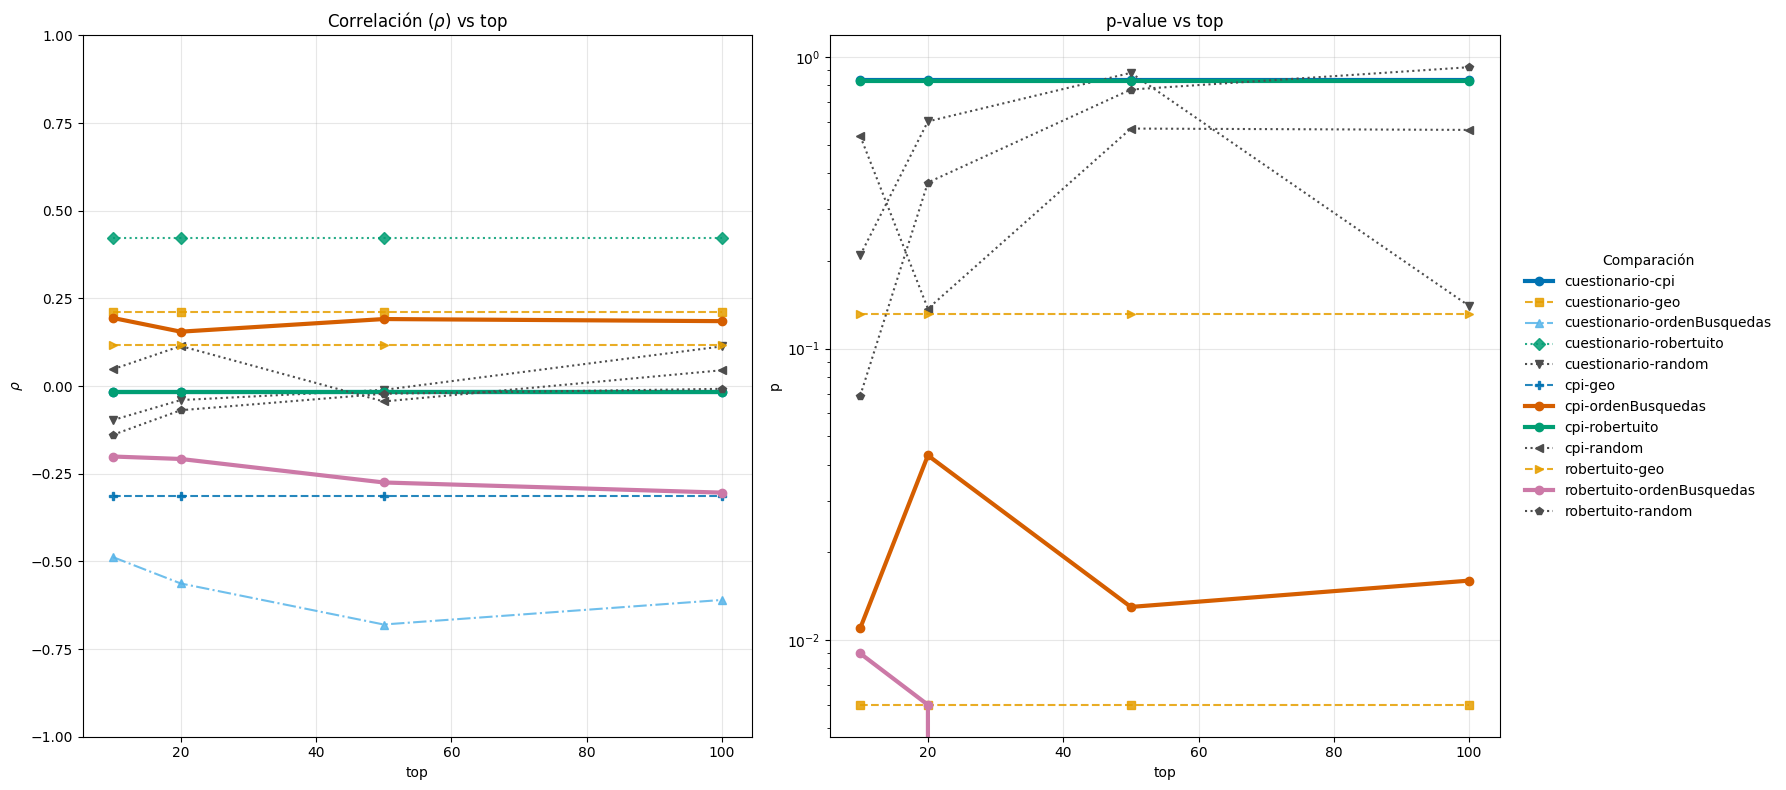

In [14]:
df_dict = {
    "cpi": df_index,
    "rankings": df_rankings,
    "page_info": df_pag_info,
    "robertuito": df_robertuito
}

method = "kendall"

all_results = []
for top in [10, 20, 50, 100]:
    # orden de rankings
    corr_dict['ordenBusquedas'], p, _ = srl.results_order_correlation(resultados, all_hrefs, top, method=method, absent_policy="1.5top")
    
    # valoracion de segmentos de rankings
    # formulario
    corr_dict['cuestionario'], _ = srl.compute_rank_feature_ponderate(df_dict['rankings'], df_dict['page_info'], weight_func=srl.inverse_rank_weight, compute_start=10)
    # robertuito
    corr_dict['robertuito'], _ = srl.compute_rank_feature_ponderate(df_dict['rankings'], df_dict['robertuito'], weight_func=srl.inverse_rank_weight, compute_start=10)

    rand = np.random.rand(n_countries, n_countries)
    rand = (rand + rand.T) / 2  # simétrica
    np.fill_diagonal(rand, 1.0)
    corr_dict['random'] = pd.DataFrame(rand, index=countries, columns=countries)

    # vectorizar matrices (solo triangular superior, sin diagonal)
    vect_dict = {k: srl.upper_tri_vals(corr_dict[k]) for k in corr_dict if k != 'index-index'}

    rp_dict = {}
    titles = []
    # correlación entre evaluación y otras matrices
    for source in ["cuestionario", 'cpi', 'robertuito']:
        rp_dict.update({source+'-'+k: spearmanr(vect_dict[source], vect_dict[k]) for k in vect_dict if k not in [source, 'index-index']})
    
    for d in ['cpi-cuestionario', 'robertuito-cpi', 'robertuito-cuestionario']:
        rp_dict.pop(d) 
    
    results = pd.DataFrame({
        "comparacion": rp_dict.keys(),
        "r": [rp_dict[k][0] for k in rp_dict],
        "p": [rp_dict[k][1] for k in rp_dict],
        "top": top
    })
    results = results.round(3)

    all_results.append(results)

    print("=" * 50)
    print(f"Top {top} resultados:")
    print("-" * 50)
    print(results)
    print("=" * 50+'\n')


# Combinar resultados de todos los tops
df_all = pd.concat(all_results, ignore_index=True)
df_all["comparacion"] = pd.Categorical(df_all["comparacion"], categories=rp_dict.keys())
#print(df_all)
# Pivot para los coeficientes de correlación (r)
wide_r = df_all.pivot(index="top", columns="comparacion", values="r").sort_index()
#print(wide_r)
# Pivot para los p-values
wide_p = df_all.pivot(index="top", columns="comparacion", values="p").sort_index()
#print(wide_p)

cols = wide_r.columns  # o wide_p.columns; idealmente iguales
style_map = srl.build_style_map(cols)

HIGHLIGHT = {
    "cuestionario-cpi",
    "cpi-ordenBusquedas",
    "cpi-robertuito",
    "robertuito-ordenBusquedas",
}

def is_random(lab: str) -> bool:
    return ("-random" in lab) or lab.startswith("random-") or lab.endswith("-random")

# Colores llamativos (puedes cambiarlos)
HIGHLIGHT_COLORS = {
    "cuestionario-cpi": "#0072B2",          # azul
    "cpi-ordenBusquedas": "#D55E00",         # naranja
    "cpi-robertuito": "#009E73",            # verde-azulado
    "robertuito-ordenBusquedas": "#CC79A7", # magenta
}

for lab in cols:
    st = style_map[lab]

    if is_random(lab):
        # más sutil: gris + línea fina + punteada + transparencia
        st["color"] = "0.3"       # gris (0=negro, 1=blanco)
        st["alpha"] = 1
        st["linewidth"] = 1.5
        st["linestyle"] = ":"
        # opcional: quita marcadores
        # st["marker"] = None

    elif lab in HIGHLIGHT:
        # más llamativo: color fijo + línea gruesa + opaco
        st["color"] = HIGHLIGHT_COLORS.get(lab, st["color"])
        st["alpha"] = 1.0
        st["linewidth"] = 3.0
        st["linestyle"] = "-"
        st["marker"] = "o"

    else:
        # resto: intermedio
        st.setdefault("alpha", 0.85)
        st.setdefault("linewidth", 1.5)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Figura para r
ax1 = srl.plot_wide(wide_r, title=r"Correlación ($\rho$) vs top", ylab=r"$\rho$", style_map=style_map, ylim=(-1, 1), ax=axes[0], show_legend=False)

# Figura para p
ax2 = srl.plot_wide(wide_p, title="p-value vs top", ylab="p", style_map=style_map, log_scale=True, ax=axes[1])
plt.show()